## Step 1: Imports

In [34]:
import math
import numpy as np
import torch
import torch.nn as nn
import torch.utils
import torch.utils.data
from torchvision import datasets, transforms
from torch.autograd import Variable
import matplotlib.pyplot as plt 
from scipy.ndimage import rotate
from torch.distributions.uniform import Uniform
from torch.distributions.normal import Normal
import scipy.sparse as sp
from scipy.linalg import block_diag
from torch.nn.parameter import Parameter
from torch.nn.modules.module import Module
import torch.nn.functional as F
import copy
import time
from torch_scatter import scatter_mean, scatter_max, scatter_add
from torch_geometric.utils import remove_self_loops,add_self_loops
from torch_geometric.datasets import Planetoid
import networkx as nx
import cebra.datasets
import scipy.io as sio
import torch_scatter
import inspect
import pickle
from scipy import sparse
import os

In [2]:
from scipy.signal import argrelextrema


In [3]:
# %load_ext cudf.pandas
import pandas as pd

In [ ]:
import seaborn as sns
from matplotlib.collections import LineCollection
from nilearn import datasets, input_data, plotting, connectome

In [50]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mutual_info_score
from sklearn import metrics
from sklearn.manifold import TSNE
from functools import reduce

In [6]:
import gc 
from concurrent.futures import ProcessPoolExecutor


In [8]:
from matplotlib.colors import ListedColormap
import plotly.graph_objs as go

In [9]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.utils import shuffle


## Step 2: Utility functions

In [ ]:

def uniform(size, tensor):
    stdv = 1.0 / math.sqrt(size)
    if tensor is not None:
        tensor.data.uniform_(-stdv, stdv)


def glorot(tensor):
    stdv = math.sqrt(6.0 / (tensor.size(0) + tensor.size(1)))
    if tensor is not None:
        tensor.data.uniform_(-stdv, stdv)


def zeros(tensor):
    if tensor is not None:
        tensor.data.fill_(0)


def ones(tensor):
    if tensor is not None:
        tensor.data.fill_(1)


def reset(nn):
    def _reset(item):
        if hasattr(item, 'reset_parameters'):
            item.reset_parameters()

    if nn is not None:
        if hasattr(nn, 'children') and len(list(nn.children())) > 0:
            for item in nn.children():
                _reset(item)
        else:
            _reset(nn)


def scatter_(name, src, index, dim_size=None):
    r"""Aggregates all values from the :attr:`src` tensor at the indices
    specified in the :attr:`index` tensor along the first dimension.
    If multiple indices reference the same location, their contributions
    are aggregated according to :attr:`name` (either :obj:`"add"`,
    :obj:`"mean"` or :obj:`"max"`).
    Args:
        name (string): The aggregation to use (:obj:`"add"`, :obj:`"mean"`,
            :obj:`"max"`).
        src (Tensor): The source tensor.
        index (LongTensor): The indices of elements to scatter.
        dim_size (int, optional): Automatically create output tensor with size
            :attr:`dim_size` in the first dimension. If set to :attr:`None`, a
            minimal sized output tensor is returned. (default: :obj:`None`)
    :rtype: :class:`Tensor`
    """

    assert name in ['add', 'mean', 'max']

    op = getattr(torch_scatter, 'scatter_{}'.format(name))
    fill_value = -1e38 if name is 'max' else 0   
    out = op(src, index, 0, None, dim_size)
    if isinstance(out, tuple):
        out = out[0]

    if name is 'max':
        out[out == fill_value] = 0

    return out


def sparse_to_tuple(sparse_mx):
    if not sp.isspmatrix_coo(sparse_mx):
        sparse_mx = sparse_mx.tocoo()
    coords = np.vstack((sparse_mx.row, sparse_mx.col)).transpose()
    values = sparse_mx.data
    shape = sparse_mx.shape
    return coords, values, shape

In [11]:
# Example usage
size = 10
tensor = torch.empty(size)
uniform(size, tensor)
print(tensor)

tensor([ 0.1867, -0.0328, -0.2776,  0.1609, -0.2141,  0.0367,  0.1585,  0.2365,
        -0.1592, -0.3029])


In [12]:
# Example usage
        
# Define a tensor with size (3, 4)
tensor = torch.empty(3, 4)

# Initialize the tensor using the glorot function
glorot(tensor)

# Print the initialized tensor
print(tensor)

tensor([[-0.3683,  0.7448,  0.0698, -0.2254],
        [ 0.1174,  0.5090, -0.4754, -0.5451],
        [-0.3644,  0.7407, -0.3415, -0.4986]])


In [13]:
# Example usage
# Define a simple neural network
class MyNet(nn.Module):
    def __init__(self):
        super(MyNet, self).__init__()
        self.fc1 = nn.Linear(10, 5)
        self.fc2 = nn.Linear(5, 2)

    def forward(self, x):
        x = self.fc1(x)
        x = self.fc2(x)
        return x

# Create an instance of the neural network
net = MyNet()

# Print the initial parameters of the neural network
print("Initial parameters:")
for name, param in net.named_parameters():
    print(name, param)


reset(net)

# Print the reset parameters of the neural network
print("\nReset parameters:")
for name, param in net.named_parameters():
    print(name, param)

Initial parameters:
fc1.weight Parameter containing:
tensor([[ 0.2962,  0.1813,  0.2725, -0.0706, -0.2451, -0.0600,  0.1461,  0.3069,
         -0.3099, -0.2227],
        [ 0.3027, -0.0653,  0.0460,  0.2496, -0.2823,  0.2195,  0.1292, -0.3077,
         -0.0370, -0.2983],
        [ 0.3015,  0.1979,  0.2759, -0.0197, -0.2001, -0.2507,  0.3162, -0.1720,
         -0.0698, -0.1130],
        [-0.3078, -0.2739, -0.1167, -0.1994,  0.1348,  0.1155, -0.0877,  0.1600,
          0.0370,  0.2427],
        [-0.0759,  0.2684,  0.1244,  0.2836,  0.0913, -0.1890, -0.1382,  0.2772,
         -0.2394,  0.0193]], requires_grad=True)
fc1.bias Parameter containing:
tensor([ 0.2375,  0.2771, -0.2322, -0.0966, -0.1351], requires_grad=True)
fc2.weight Parameter containing:
tensor([[ 0.1951, -0.1953, -0.3220,  0.0865, -0.3626],
        [-0.3444,  0.0799, -0.0995,  0.1446,  0.0449]], requires_grad=True)
fc2.bias Parameter containing:
tensor([0.4376, 0.1323], requires_grad=True)

Reset parameters:
fc1.weight Parame

In [14]:
# Example usage

 # Define the source tensor
src = torch.tensor([[1, 2, 3], [4, 5, 6], [7, 8, 9]])

# Define the index tensor
index = torch.tensor([0, 1, 0])

# Call the scatter_() function with the "add" aggregation
out = scatter_('add', src, index)

# Print the output tensor
print(out)

tensor([[ 8, 10, 12],
        [ 4,  5,  6]])


In [15]:

class MessagePassing(torch.nn.Module):
    r"""Base class for creating message passing layers
    .. math::
        \mathbf{x}_i^{\prime} = \gamma_{\mathbf{\Theta}} \left( \mathbf{x}_i,
        \square_{j \in \mathcal{N}(i)} \, \phi_{\mathbf{\Theta}}
        \left(\mathbf{x}_i, \mathbf{x}_j,\mathbf{e}_{i,j}\right) \right),
    where :math:`\square` denotes a differentiable, permutation invariant
    function, *e.g.*, sum, mean or max, and :math:`\gamma_{\mathbf{\Theta}}`
    and :math:`\phi_{\mathbf{\Theta}}` denote differentiable functions such as
    MLPs.
    See `here <https://rusty1s.github.io/pytorch_geometric/build/html/notes/
    create_gnn.html>`__ for the accompanying tutorial.
    """

    def __init__(self, aggr='add'):
        super(MessagePassing, self).__init__()


        message_signature = inspect.signature(self.message)
        # Extract the names of parameters excluding the first one (self for methods)
        self.message_args = [param.name for param in message_signature.parameters.values()][0:]
        update_signature = inspect.signature(self.update)
        # Extract the names of parameters excluding the first one (self for methods)
        self.update_args = [param.name for param in update_signature.parameters.values()][1:]

    def propagate(self, aggr, edge_index, **kwargs):
        r"""The initial call to start propagating messages.
        Takes in an aggregation scheme (:obj:`"add"`, :obj:`"mean"` or
        :obj:`"max"`), the edge indices, and all additional data which is
        needed to construct messages and to update node embeddings."""

        assert aggr in ['add', 'mean', 'max']
        kwargs['edge_index'] = edge_index
        size = None
        message_args = []
        for arg in self.message_args:
            if arg[-2:] == '_i':
                tmp = kwargs[arg[:-2]]
                size = tmp.size(0)
                message_args.append(tmp[edge_index[0]])
            elif arg[-2:] == '_j':
                tmp = kwargs[arg[:-2]]
                size = tmp.size(0)
                message_args.append(tmp[edge_index[1]])
            else:
                message_args.append(kwargs[arg])

        update_args = [kwargs[arg] for arg in self.update_args]

        # Ensure there is at least one argument for the message function
        if not message_args:
            message_args.append(kwargs['x'])  # Use the node features as a default

        out = self.message(*message_args)
        out = scatter_(aggr, out, edge_index[0], dim_size=size)
        out = self.update(out, *update_args)
        return out

    def message(self, x_j):  # pragma: no cover
        r"""Constructs messages in analogy to :math:`\phi_{\mathbf{\Theta}}`
        for each edge in :math:`(i,j) \in \mathcal{E}`.
        Can take any argument which was initially passed to :meth:`propagate`.
        In addition, features can be lifted to the source node :math:`i` and
        target node :math:`j` by appending :obj:`_i` or :obj:`_j` to the
        variable name, *.e.g.* :obj:`x_i` and :obj:`x_j`."""

        return x_j


    def update(self, aggr_out):  # pragma: no cover
        r"""Updates node embeddings in analogy to
        :math:`\gamma_{\mathbf{\Theta}}` for each node
        :math:`i \in \mathcal{V}`.
        Takes in the output of aggregation as first argument and any argument
        which was initially passed to :meth:`propagate`."""

        return aggr_out
    

# Example usage

# Create an instance of the MessagePassing class
mp = MessagePassing()

# Define the graph with three nodes and two directed edges
edge_index = torch.tensor([[0, 1, 1, 2, 2], [1, 0, 2, 1, 2]], dtype=torch.long)

# Create initial node features
x = torch.tensor([[1.0, 2.0], [3.0, 4.0], [5.0, 6.0]], dtype=torch.float)



# Propagate messages and update node embeddings
output = mp.propagate('add', edge_index, x=x)

# Print the results
print("Original Node Features:")
print(x)
print("\nEdge Index:")
print(edge_index)
print("\nOutput after Propagation and Update:")
print(output)


Original Node Features:
tensor([[1., 2.],
        [3., 4.],
        [5., 6.]])

Edge Index:
tensor([[0, 1, 1, 2, 2],
        [1, 0, 2, 1, 2]])

Output after Propagation and Update:
tensor([[ 3.,  4.],
        [ 6.,  8.],
        [ 8., 10.]])


In [16]:
def tuple_to_array(lot):
    out = np.array(list(lot[0]))
    for i in range(1, len(lot)):
        out = np.vstack((out, np.array(list(lot[i]))))
    
    return out

In [17]:
# Example usage
lot = [(1, 2, 3), (4, 5, 6), (7, 8, 9)]
result = tuple_to_array(lot)
print(result)

[[1 2 3]
 [4 5 6]
 [7 8 9]]


## Step 3: Edge Extraction

In [18]:
# def extract_edges(adjs_list):
#     edges_list = []
#     for i in range(0, len(adjs_list)):
        
#         adj = adjs_list[i]
#         adj.eliminate_zeros()        
#         adj_triu = sp.triu(adj)
#         adj_tuple = sparse_to_tuple(adj_triu)
#         edges = adj_tuple[0]
#         edges_list.append(edges)
#     return edges_list


def extract_edges(adjs_list):
    edge_indices_list = []
    
    for adj in adjs_list:
        # Extract the non-zero indices (edges) from the sparse matrix
        rows, cols = adj.nonzero()
        edge_indices = [[row, col] for row, col in zip(rows, cols)]
        edge_indices_list.append(edge_indices)

    return edge_indices_list

In [19]:
# Example usage
# Create an adjacency matrix

temp_matrix = np.random.randint(2, size=(5, 5))
temp_adj = np.triu(temp_matrix) + np.triu(temp_matrix, 1).T
adj = [sp.csr_matrix(temp_adj)]

edge_lists = extract_edges(adj)

print("edge lists = ", edge_lists)

edge lists =  [[[0, 0], [0, 1], [0, 2], [0, 4], [1, 0], [1, 1], [1, 2], [2, 0], [2, 1], [3, 3], [4, 0]]]


In [20]:
temp_adj

array([[1, 1, 1, 0, 1],
       [1, 1, 1, 0, 0],
       [1, 1, 0, 0, 0],
       [0, 0, 0, 1, 0],
       [1, 0, 0, 0, 0]])

In [21]:
np.transpose(edge_lists[0])

array([[0, 0, 0, 0, 1, 1, 1, 2, 2, 3, 4],
       [0, 1, 2, 4, 0, 1, 2, 0, 1, 3, 0]], dtype=int32)

## Step 4: GCN, Temporal Attention, GRU Layers

In [22]:
class GCNConv(MessagePassing):
    def __init__(self, in_channels, out_channels, act=F.relu, improved=False, bias=False):
        super(GCNConv, self).__init__()

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.improved = improved
        self.act = act

        self.weight = Parameter(torch.Tensor(in_channels, out_channels))

        if bias:
            self.bias = Parameter(torch.Tensor(out_channels))
        else:
            self.register_parameter('bias', None)

        self.reset_parameters()

    def reset_parameters(self):
        glorot(self.weight)
        zeros(self.bias)

    def forward(self, x, edge_index, edge_weight=None):
        if edge_weight is None:
            edge_weight = torch.ones(
                (edge_index.size(1), ), dtype=x.dtype, device=x.device)
        edge_weight = edge_weight.view(-1)
        assert edge_weight.size(0) == edge_index.size(1)

        #if your original networks do not have self-loops, uncomment the following:
        
        # edge_index = add_self_loops(edge_index, num_nodes=x.size(0))
        # loop_weight = torch.full(
        #     (x.size(0), ),
        #     1 if not self.improved else 2,
        #     dtype=x.dtype,
        #     device=x.device)
        # edge_weight = torch.cat([edge_weight, loop_weight], dim=0)

        row, col = edge_index
        deg = scatter_add(edge_weight, row, dim=0, dim_size=x.size(0))
        # print('deg= ',deg)
        deg_inv = deg.pow(-0.5)
        deg_inv[deg_inv == float('inf')] = 0
        # print("deg_inv = ",deg_inv)
        norm = deg_inv[row] * edge_weight * deg_inv[col]
        # print('norm = ',norm)
        # print('weigh = ', self.weight)
        x = torch.matmul(x, self.weight)
        # print('X = ',x)
        out = self.propagate('add', edge_index, x=x, norm=norm)
        return self.act(out)

    def message(self, x_j, norm):
        return norm.view(-1, 1) * x_j

    def update(self, aggr_out):
        if self.bias is not None:
            aggr_out = aggr_out + self.bias
        return aggr_out

    def __repr__(self):
        return '{}({}, {})'.format(self.__class__.__name__, self.in_channels,
                                   self.out_channels)

In [23]:
edge_index = torch.tensor([[0, 1, 1, 2, 2], [1, 0, 2, 1, 2]], dtype=torch.long)

# Create initial node features
x = torch.tensor([[1.0, 2.0], [3.0, 4.0], [5.0, 6.0]], dtype=torch.float)

In [24]:
gcn = GCNConv(2, 2, act=lambda x:x,  improved=False, bias=False)
gcn.forward( x, edge_index, edge_weight=None)

tensor([[-4.0432,  1.4384],
        [-6.2784,  2.3352],
        [-7.2240,  2.3247]], grad_fn=<ScatterAddBackward0>)

In [26]:
class AttentionLayer(nn.Module):
    """Implements an Attention Layer"""

    def __init__(self, cuda, nhid):
        super(AttentionLayer, self).__init__()
        self.nhid = nhid


        # Linear transformations for K, Q, V from the same source
        self.key = nn.Linear(nhid, nhid)
        self.query = nn.Linear(nhid, nhid)
        self.value = nn.Linear(nhid, nhid)
        self.softmax = nn.Softmax()
        self.cuda = cuda
        self.attention_weights = []

    def forward(self, all_h, attention_width,mask=None):

        temp = [tensor[-1, :, :] for tensor in all_h]
        temp = (torch.stack(temp, dim=0))
        all_attentions_weights = []
        if temp.size(0) >= 2:
            lb = temp.size(0) - attention_width
            if(lb<0):
                lb = 0

            query = self.query(temp[-1,-1,:].view(1,-1))
            keys = self.key(temp[1:,-1 ,:])
            scores = torch.matmul(query, keys.transpose(-2, -1)) / torch.sqrt(torch.tensor(self.nhid, dtype=torch.float32))
        

                
            # Apply mask (if provided)
            if mask is not None:
                scores = scores.masked_fill(mask == 0, -1e9)

            # Apply softmax
            attention_weights = F.softmax(scores, dim=1)
            all_attentions_weights.append(attention_weights)

            # print('att weights size =', attention_weights.size())
            
            values = self.value( (torch.stack(all_h[1:], dim=0)))
            # print('shape values =', values.size())
            
            expanded_weights = attention_weights.view(1, attention_weights.size(1), 1, 1, 1)
            
            weighted_values = values * expanded_weights
            # print('wieghted values size = ', weighted_values.size())
            
            # Sum along the first dimension to get the final weighted sum tensor 
            weighted_sum = torch.sum(weighted_values, dim=1).squeeze(dim=0)
            # print('final tensor size = ', weighted_sum.size())
            all_h[-1] = weighted_sum

       
        return all_h,all_attentions_weights
    
        



In [27]:
# Example usage
temp_tensor = [torch.rand(1,3,4) for _ in range(6)]
att_layer = AttentionLayer(cuda = False, nhid=4)
att_layer.forward(temp_tensor, 3)

([tensor([[[0.2524, 0.3791, 0.9006, 0.8189],
           [0.3577, 0.7015, 0.9230, 0.8434],
           [0.9629, 0.3120, 0.3296, 0.6542]]]),
  tensor([[[0.5721, 0.2939, 0.2678, 0.6067],
           [0.9044, 0.9368, 0.1180, 0.2064],
           [0.0534, 0.0890, 0.6633, 0.6398]]]),
  tensor([[[0.6649, 0.0709, 0.2156, 0.5047],
           [0.1333, 0.2343, 0.2601, 0.2459],
           [0.4518, 0.3714, 0.0926, 0.5718]]]),
  tensor([[[0.1609, 0.2182, 0.3835, 0.1807],
           [0.3646, 0.3174, 0.2172, 0.5407],
           [0.5960, 0.6941, 0.5049, 0.6801]]]),
  tensor([[[0.4651, 0.2211, 0.8967, 0.1023],
           [0.7265, 0.0944, 0.5469, 0.6292],
           [0.1546, 0.3913, 0.6789, 0.5401]]]),
  tensor([[[-0.5063, -0.0501, -0.2377, -0.0905],
           [-0.5245, -0.0894, -0.2463, -0.0755],
           [-0.5320, -0.1036, -0.1879, -0.1070]]], grad_fn=<SqueezeBackward1>)],
 [tensor([[0.2057, 0.1928, 0.1978, 0.2026, 0.2010]], grad_fn=<SoftmaxBackward0>)])

In [28]:
class graph_gru_attention(nn.Module):
    def __init__(self, input_size, hidden_size, n_layer, bias=True):
        super(graph_gru_attention, self).__init__()

        self.hidden_size = hidden_size
        self.n_layer = n_layer
        cuda=False
        attention_width= 3
        # gru weights
        self.weight_xz = []
        self.weight_hz = []
        self.weight_xr = []
        self.weight_hr = []
        self.weight_xh = []
        self.weight_hh = []
        
        self.attention_width = attention_width
        self.AttentionLayer = AttentionLayer(cuda,hidden_size)
        
        for i in range(self.n_layer):
            if i==0:
                self.weight_xz.append(GCNConv(input_size, hidden_size, act=lambda x:x, bias=bias))
                self.weight_hz.append(GCNConv(hidden_size, hidden_size, act=lambda x:x, bias=bias))
                self.weight_xr.append(GCNConv(input_size, hidden_size, act=lambda x:x, bias=bias))
                self.weight_hr.append(GCNConv(hidden_size, hidden_size, act=lambda x:x, bias=bias))
                self.weight_xh.append(GCNConv(input_size, hidden_size, act=lambda x:x, bias=bias))
                self.weight_hh.append(GCNConv(hidden_size, hidden_size, act=lambda x:x, bias=bias))
            else:
                self.weight_xz.append(GCNConv(hidden_size, hidden_size, act=lambda x:x, bias=bias))
                self.weight_hz.append(GCNConv(hidden_size, hidden_size, act=lambda x:x, bias=bias))
                self.weight_xr.append(GCNConv(hidden_size, hidden_size, act=lambda x:x, bias=bias))
                self.weight_hr.append(GCNConv(hidden_size, hidden_size, act=lambda x:x, bias=bias))
                self.weight_xh.append(GCNConv(hidden_size, hidden_size, act=lambda x:x, bias=bias))
                self.weight_hh.append(GCNConv(hidden_size, hidden_size, act=lambda x:x, bias=bias))
    
    def forward(self, inp, edgidx, all_h):
        h_hat = torch.zeros(all_h[-1].size())
        for i in range(self.n_layer):
            if i==0:
                s_g = torch.sigmoid(self.weight_xz[i](inp, edgidx) + self.weight_hz[i](all_h[-1][i], edgidx))
                r_g = torch.sigmoid(self.weight_xr[i](inp, edgidx) + self.weight_hr[i](all_h[-1][i], edgidx))
                h_tilde_g = torch.tanh(self.weight_xh[i](inp, edgidx) + self.weight_hh[i](r_g * all_h[-1][i], edgidx))
                h_hat[i] = s_g * all_h[-1][i] + (1 - s_g) * h_tilde_g
                
            else:

                s_g = torch.sigmoid(self.weight_xz[i](h_hat[i-1], edgidx) + self.weight_hz[i](all_h[-1][i], edgidx))
                r_g = torch.sigmoid(self.weight_xr[i](h_hat[i-1], edgidx) + self.weight_hr[i](all_h[-1][i], edgidx))
                h_tilde_g = torch.tanh(self.weight_xh[i](h_hat[i-1], edgidx) + self.weight_hh[i](r_g * all_h[-1][i], edgidx))
                h_hat[i] = s_g * all_h[-1][i] + (1 - s_g) * h_tilde_g
                
        all_h.append(h_hat)
        
        all_h, attention_weights = self.AttentionLayer.forward(all_h,self.attention_width)
        
        out = all_h[-1]
        return all_h, out, attention_weights


In [29]:
class InnerProductDecoder(nn.Module):
    def __init__(self, act=torch.sigmoid, dropout=0.):
        super(InnerProductDecoder, self).__init__()
        
        self.act = act
        self.dropout = dropout
    
    def forward(self, inp):
        inp = F.dropout(inp, self.dropout, training=self.training)
        x = torch.transpose(inp, dim0=0, dim1=1)
        x = torch.mm(inp, x)
        return self.act(x)

## Step 5: Temporal Attention-enhanced Variational Graph Recurrent Neural Network (TAVRNN) Model

In [30]:
class T_AVRNN(nn.Module):
    def __init__(self, x_dim, h_dim, z_dim, n_layers, eps, bias=False):
        super(T_AVRNN, self).__init__()
        
        self.x_dim = x_dim
        self.eps = eps
        self.h_dim = h_dim
        self.z_dim = z_dim
        self.n_layers = n_layers
        
        self.phi_x = nn.Sequential(nn.Linear(x_dim, h_dim), nn.ReLU())
        self.phi_z = nn.Sequential(nn.Linear(z_dim, h_dim), nn.ReLU())
        
        self.enc = GCNConv(h_dim + h_dim, h_dim)            
        self.enc_mean = GCNConv(h_dim, z_dim, act=lambda x:x)
        self.enc_std = GCNConv(h_dim, z_dim, act=F.softplus)
        
        self.prior = nn.Sequential(nn.Linear(h_dim, h_dim), nn.ReLU())
        self.prior_mean = nn.Sequential(nn.Linear(h_dim, z_dim))
        self.prior_std = nn.Sequential(nn.Linear(h_dim, z_dim), nn.Softplus())
        
        self.rnn = graph_gru_attention(h_dim + h_dim, h_dim, n_layers, bias)
            
  
    
    def forward(self, x, edge_idx_list, adj_orig_dense_list, hidden_in=None):
        assert len(adj_orig_dense_list) == len(edge_idx_list)
        
        kld_loss = 0
        nll_loss = 0
        all_enc_mean, all_enc_std = [], []
        all_prior_mean, all_prior_std = [], []
        all_dec_t, all_z_t = [], []
        all_h = []
        all_attention_weights = []
        
        if hidden_in is None:
            h = Variable(torch.zeros(self.n_layers, x.size(1), self.h_dim))
        else:
            h = Variable(hidden_in)

        all_h.append(h)
        for t in range(x.size(0)):
            phi_x_t = self.phi_x(x[t])
            
            #encoder
            # print('phi(x) size = ', phi_x_t.size())
            # print('h[-1] size =', h[-1].size())
            enc_t = self.enc(torch.cat([phi_x_t, h[-1]], 1), edge_idx_list[t])
            # print('enc_t size = ',enc_t.size())
            enc_mean_t = self.enc_mean(enc_t, edge_idx_list[t])
            # print('enc_mean_t size = ',enc_mean_t.size())
            enc_std_t = self.enc_std(enc_t, edge_idx_list[t])
            # print('enc_std_t size = ',enc_std_t.size())
            
            #prior
            prior_t = self.prior(h[-1])
            # print('prior_t size = ',prior_t.size())
            prior_mean_t = self.prior_mean(prior_t)
            # print('prior_mean_t size = ',prior_mean_t.size())
            prior_std_t = self.prior_std(prior_t)
            # print('prior_std_t size = ',prior_std_t.size())
            
            #sampling and reparameterization
            z_t = self._reparameterized_sample(enc_mean_t, enc_std_t)
            # print('z_t size = ,',z_t.size())
            phi_z_t = self.phi_z(z_t)
            # print('phi_z_t size = ',phi_z_t.size())
            
            #decoder
            dec_t = self.dec(z_t)
            
            #recurrence
            all_h, h , attention_weights_t = self.rnn(torch.cat([phi_x_t, phi_z_t], 1), edge_idx_list[t], all_h)
            
            nnodes = adj_orig_dense_list[t].size()[0]
            enc_mean_t_sl = enc_mean_t[0:nnodes, :]
            enc_std_t_sl = enc_std_t[0:nnodes, :]
            prior_mean_t_sl = prior_mean_t[0:nnodes, :]
            prior_std_t_sl = prior_std_t[0:nnodes, :]
            dec_t_sl = dec_t[0:nnodes, 0:nnodes]
            
            #computing losses
            kld_loss += self._kld_gauss(enc_mean_t_sl, enc_std_t_sl, prior_mean_t_sl, prior_std_t_sl)
            nll_loss += self._nll_bernoulli(dec_t_sl, adj_orig_dense_list[t])
            
            # all_enc_std.append(enc_std_t_sl)
            # all_enc_mean.append(enc_mean_t_sl)
            # all_prior_mean.append(prior_mean_t_sl)
            # all_prior_std.append(prior_std_t_sl)
            # all_dec_t.append(dec_t_sl)
            all_z_t.append(z_t)
            all_attention_weights.append(attention_weights_t)
        return kld_loss, nll_loss, all_z_t , all_attention_weights,all_h
    
    def dec(self, z):
        outputs = InnerProductDecoder(act=lambda x:x)(z)
        return outputs
    
    def reset_parameters(self, stdv=1e-1):
        for weight in self.parameters():
            weight.data.normal_(0, stdv)
     
    def _init_weights(self, stdv):
        pass
    
    def _reparameterized_sample(self, mean, std):
        eps1 = torch.FloatTensor(std.size()).normal_()
        eps1 = Variable(eps1)
        return eps1.mul(std).add_(mean)
    
    def _kld_gauss(self, mean_1, std_1, mean_2, std_2):
        num_nodes = mean_1.size()[0]
        kld_element =  (2 * torch.log(std_2 + self.eps) - 2 * torch.log(std_1 + self.eps) +
                        (torch.pow(std_1 + self.eps ,2) + torch.pow(mean_1 - mean_2, 2)) / 
                        torch.pow(std_2 + self.eps ,2) - 1)
        return (0.5 / num_nodes) * torch.mean(torch.sum(kld_element, dim=1), dim=0)
    
    def _kld_gauss_zu(self, mean_in, std_in):
        num_nodes = mean_in.size()[0]
        std_log = torch.log(std_in + self.eps)
        kld_element =  torch.mean(torch.sum(1 + 2 * std_log - mean_in.pow(2) -
                                            torch.pow(torch.exp(std_log), 2), 1))
        return (-0.5 / num_nodes) * kld_element
    
    def _nll_bernoulli(self, logits, target_adj_dense):
        temp_size = target_adj_dense.size()[0]
        temp_sum = target_adj_dense.sum()
        posw = float(temp_size * temp_size - temp_sum) / temp_sum
        norm = temp_size * temp_size / float((temp_size * temp_size - temp_sum) * 2)
        nll_loss_mat = F.binary_cross_entropy_with_logits(input=logits
                                                          , target=target_adj_dense
                                                          , pos_weight=posw
                                                          , reduction='none')
        nll_loss = -1 * norm * torch.mean(nll_loss_mat, dim=[0,1])
        return - nll_loss

### Rat Hippocampus data

In [35]:
hippocampus_pos = cebra.datasets.init('rat-hippocampus-single-achilles')


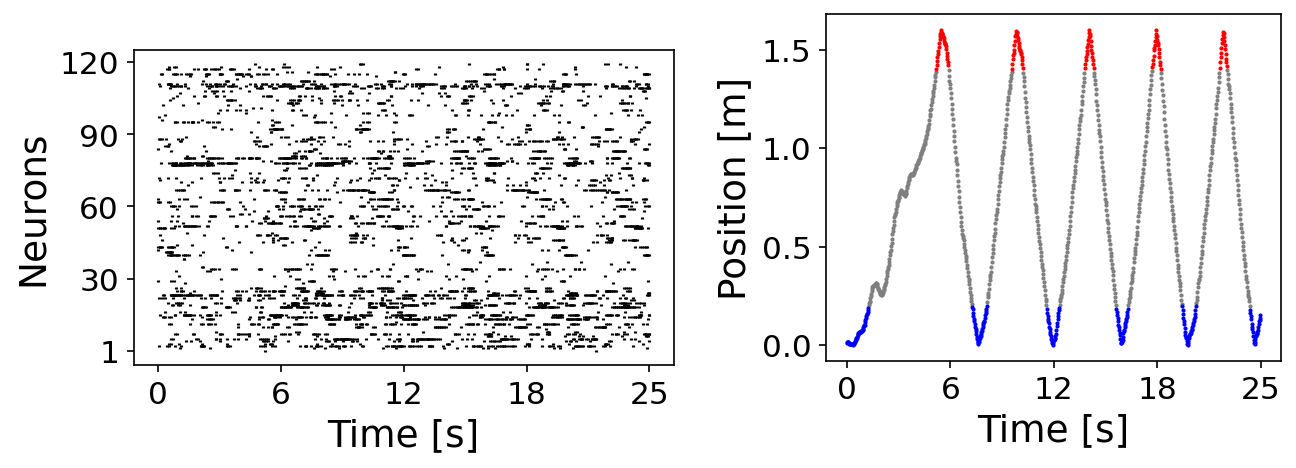

In [36]:
fig = plt.figure(figsize=(9,3), dpi=150)
plt.subplots_adjust(wspace = 0.3)
ax = plt.subplot(121)
ax.set_position([0.05, 0.1, 0.4, 0.7])  # [left, bottom, width, height]
spike_indices = np.nonzero(hippocampus_pos.neural.numpy()[:1000].T)
# ax.imshow(hippocampus_pos.neural.numpy()[:1000].T, aspect = 'auto', cmap = 'gray_r')
plt.scatter(spike_indices[1], spike_indices[0], marker='|', color='black',s=2)
plt.ylabel('Neurons',fontsize =18)
plt.xlabel('Time [s]',fontsize =18)
plt.xticks(np.linspace(0, 1000, 5), np.linspace(0, 0.025*1000, 5, dtype = int))
plt.yticks(np.linspace(0, 120, 5), [1,30,60,90,120])
plt.tick_params(axis='both', which='major', labelsize=15)

ax2 = plt.subplot(122)

# Values for plotting
time_points = np.arange(1000)
position_values = hippocampus_pos.continuous_index[:1000, 0]

# Create masks for different conditions
mask_blue = position_values < 0.2
mask_red = (position_values >= 1.4) & (position_values <= 1.6)
mask_gray = ~mask_blue & ~mask_red  # Everything else is gray

# ax2.scatter(np.arange(1000), hippocampus_pos.continuous_index[:1000,0], c = 'gray', s=1)
# Scatter plot for different conditions
ax2.scatter(time_points[mask_gray], position_values[mask_gray], c='gray', s=1, label='Other Values')
ax2.scatter(time_points[mask_blue], position_values[mask_blue], c='blue', s=1, label='Values < 0.2')
ax2.scatter(time_points[mask_red], position_values[mask_red], c='red', s=1, label='1.4 <= Values <= 1.6')

plt.ylabel('Position [m]',fontsize =18)
plt.xlabel('Time [s]',fontsize =18)
plt.tick_params(axis='both', which='major', labelsize=15)
plt.xticks(np.linspace(0, 1000, 5), np.linspace(0, 0.025*1000, 5, dtype = int))
plt.savefig('./ICLR_figs/hippocampus_rat.pdf', format='pdf',bbox_inches = 'tight')
plt.show()

In [37]:
hippocampus_pos.neural.numpy().shape

(10178, 120)

In [38]:
hippocampus_pos.continuous_index[:1000,0][0:10]

tensor([0.0111, 0.0148, 0.0148, 0.0145, 0.0143, 0.0113, 0.0070, 0.0048, 0.0073,
        0.0057])

In [39]:
discrete_pos = hippocampus_pos.continuous_index.clone()

discrete_pos[(discrete_pos[:, 0] >= 0) & (discrete_pos[:, 0] < 0.2), 0] = 1
discrete_pos[(discrete_pos[:, 0] >= 1.5) & (discrete_pos[:, 0] < 1.7), 0] = -1


In [40]:
binary_indices = torch.where((discrete_pos[:, 0] == 1) | (discrete_pos[:, 0] == -1))[0]
discrete_pos = discrete_pos[binary_indices]

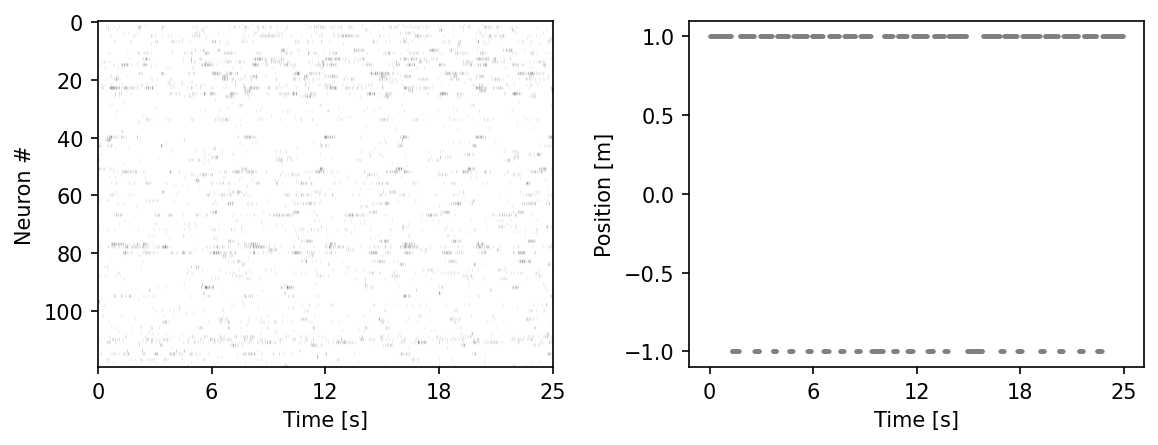

In [41]:
fig = plt.figure(figsize=(9,3), dpi=150)
plt.subplots_adjust(wspace = 0.3)
ax = plt.subplot(121)
ax.imshow(hippocampus_pos.neural.numpy()[:1000].T, aspect = 'auto', cmap = 'gray_r')
plt.ylabel('Neuron #')
plt.xlabel('Time [s]')
plt.xticks(np.linspace(0, 1000, 5), np.linspace(0, 0.025*1000, 5, dtype = int))

ax2 = plt.subplot(122)
ax2.scatter(np.arange(1000), discrete_pos[:1000,0], c = 'gray', s=1)
plt.ylabel('Position [m]')
plt.xlabel('Time [s]')
plt.xticks(np.linspace(0, 1000, 5), np.linspace(0, 0.025*1000, 5, dtype = int))
plt.show()

In [42]:
neural_data = hippocampus_pos.neural.numpy().T.copy()
neural_data = neural_data[:,binary_indices]

In [43]:
# Function to find windows where the values change
def find_change_windows(tensor):
    values = tensor[:, 0]  # Extract the first dimension
    windows = []
    start_idx = 0

    for i in range(1, len(values)):
        if values[i] != values[i - 1]:
            windows.append((start_idx, i - 1))
            start_idx = i

    # Add the final window
    windows.append((start_idx, len(values) - 1))

    return windows



In [44]:
all_windows = find_change_windows(discrete_pos)


In [45]:
window_labels = []
for window in all_windows:
    start = window[0]
    label = discrete_pos[start,0]
    window_labels.append(label)

In [46]:
def stcc(spike_train1, spike_train2):
    mean1 = np.mean(spike_train1)
    mean2 = np.mean(spike_train2)
    
    auto_cov1 = np.sum((spike_train1 - mean1)**2)
    auto_cov2 = np.sum((spike_train2 - mean2)**2)
    
    cross_cov = np.sum((spike_train1 - mean1) * (spike_train2 - mean2))
    
    stcc_value = cross_cov / np.sqrt(auto_cov1 * auto_cov2)
    
    return stcc_value

In [47]:
def shuffle_matrix(X):
    """Shuffle time points independently for each channel."""
    shuffled_X = np.copy(X)
    for i in range(X.shape[0]):
        shuffled_X[i, :] = np.random.permutation(shuffled_X[i, :])
    return shuffled_X

def compute_covariance_matrix(X):
    """Compute the covariance matrix of X."""
    return np.cov(X, rowvar=True)

def marchenko_pastur_confidence_intervals(X, num_shuffles=1000, confidence_level=0.95):
    """Compute the confidence intervals for eigenvalues using shuffled controls."""
    eigenvalues_shuffled = []
    
    for _ in range(num_shuffles):
        shuffled_X = shuffle_matrix(X)
        shuffled_cov = compute_covariance_matrix(shuffled_X)
        eigenvalues_shuffled.extend(np.linalg.eigvalsh(shuffled_cov))
    
    # Compute the empirical confidence intervals
    eigenvalues_shuffled = np.sort(eigenvalues_shuffled)
    lower_bound = np.percentile(eigenvalues_shuffled, (1 - confidence_level) / 2 * 100)
    upper_bound = np.percentile(eigenvalues_shuffled, (1 + confidence_level) / 2 * 100)
    
    return lower_bound, upper_bound


def filter_correlation_matrix(cov_matrix, lower_bound, upper_bound):
    # Eigen-decomposition
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
    
    # Determine which eigenvalues are reliable
    reliable_indices = (eigenvalues < lower_bound) | (eigenvalues > upper_bound)
    
    # Reconstruct the reliable part of the covariance matrix
    reliable_cov_matrix = np.dot(eigenvectors[:, reliable_indices],
                                 np.dot(np.diag(eigenvalues[reliable_indices]),
                                        eigenvectors[:, reliable_indices].T))
    
    # Compute the filtered correlation matrix
    d = np.sqrt(np.diag(reliable_cov_matrix))
    filtered_corr_matrix = reliable_cov_matrix / np.outer(d, d)
    filtered_corr_matrix[filtered_corr_matrix > 1] = 1  # Numerical precision fix
    filtered_corr_matrix[filtered_corr_matrix < -1] = -1
    
    return filtered_corr_matrix

In [ ]:
all_connectivity_matrices = []
for window in all_windows:
# for start in range(0, 4):
    start = window[0]
    end = window[1]+1

    # Extract the current window of data
    current_window = neural_data[:, start:end]

    
    # Calculate functional connectivity (correlation in this case)
    current_window[np.isnan(current_window)] = 0

    
    
    connectivity_matrix = np.corrcoef(current_window)
    connectivity_matrix[np.isnan(connectivity_matrix)] = 0

  
    # Compute confidence intervals using shuffled controls
    lower_bound, upper_bound = marchenko_pastur_confidence_intervals(current_window)
    filtered_corr_matrix = filter_correlation_matrix(connectivity_matrix, lower_bound, upper_bound)
    filtered_corr_matrix[np.isnan(filtered_corr_matrix)] = 0
    np.fill_diagonal(filtered_corr_matrix, 1)
    all_connectivity_matrices.append(filtered_corr_matrix)


   

In [51]:
sample_index = np.arange(0,len(all_connectivity_matrices))

In [52]:
sampled_connectivity_matrices = np.array(all_connectivity_matrices)[sample_index]


In [53]:
adj_time_list = [sp.csr_matrix(connectivity_mat) for  connectivity_mat in sampled_connectivity_matrices]

In [54]:
# file_path = f'./Baselines/Dataset/adj_time_list_hippocampus_rat.pkl'

# # Save the list to a pickle file
# with open(file_path, 'wb') as f:
#     pickle.dump(adj_time_list, f)

In [55]:
### Weighted Adjacency Matrix
threshold = 0
edge_weights = [torch.tensor(np.abs(np.where(np.abs(connectivity_matrix.toarray()) < 0, 0, connectivity_matrix.toarray())), dtype=torch.float32) for connectivity_matrix in adj_time_list]

edge_weights_threshold = [torch.tensor(np.abs(np.where(np.abs(connectivity_matrix.toarray()) < threshold, 0, connectivity_matrix.toarray())), dtype=torch.float32) for connectivity_matrix in adj_time_list]

### Binary Adjacency Matrix
adj_orig_dense_list = [(weighted_matrix != 0).int() for weighted_matrix in edge_weights_threshold] 

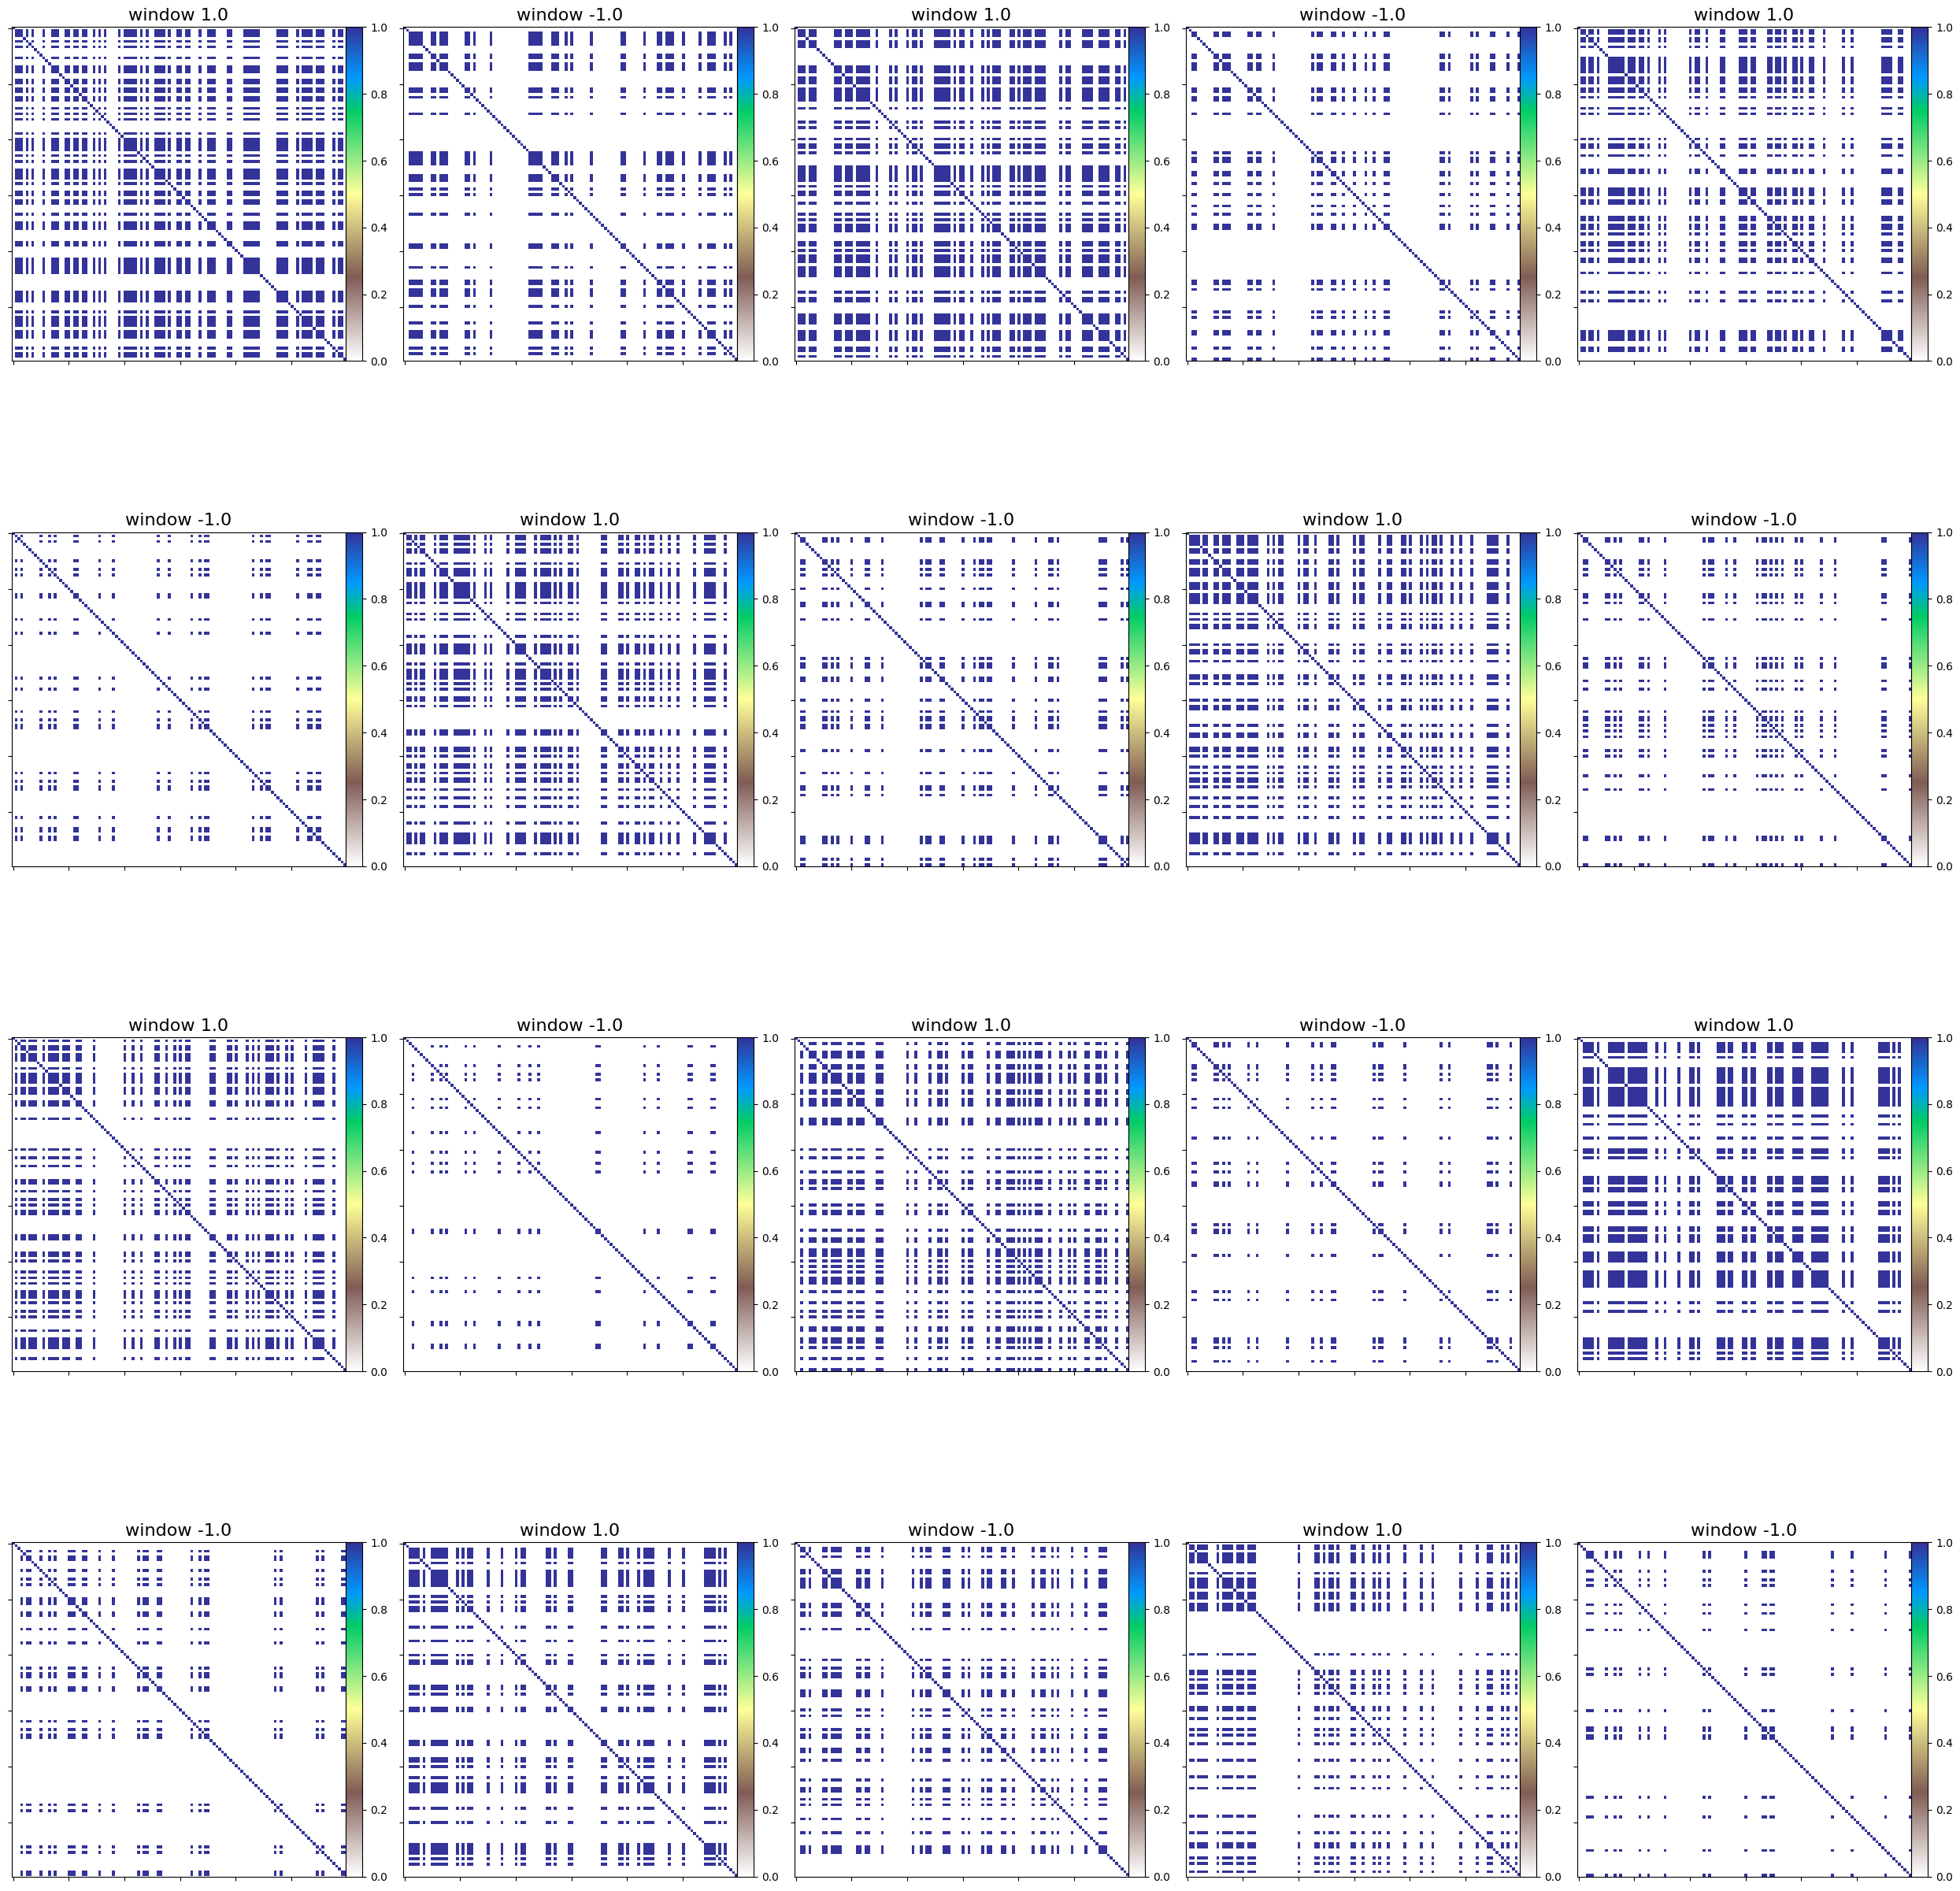

In [56]:
fig = plt.figure(figsize=(25, 40))


j = 0
for i in range(0,20):
    adjacency_matrix_array = adj_orig_dense_list[i].numpy()
    
    ax = fig.add_subplot(4, 5, j + 1)
    j += 1
    plotting.plot_matrix(adjacency_matrix_array, figure=fig, colorbar=True, vmax=1, vmin=0, cmap='terrain_r')
    
        
    ax.set_title(f'window {discrete_pos[all_windows[i][0],0]}',fontsize=16)

plt.tight_layout()
plt.show()

In [57]:
# Flatten each adjacency matrix and stack them
flattened_matrices = np.array([adj.flatten() for adj in adj_orig_dense_list])

# Compute the cosine similarity matrix
similarity_matrix = cosine_similarity(flattened_matrices)

In [58]:
# similarity_matrix

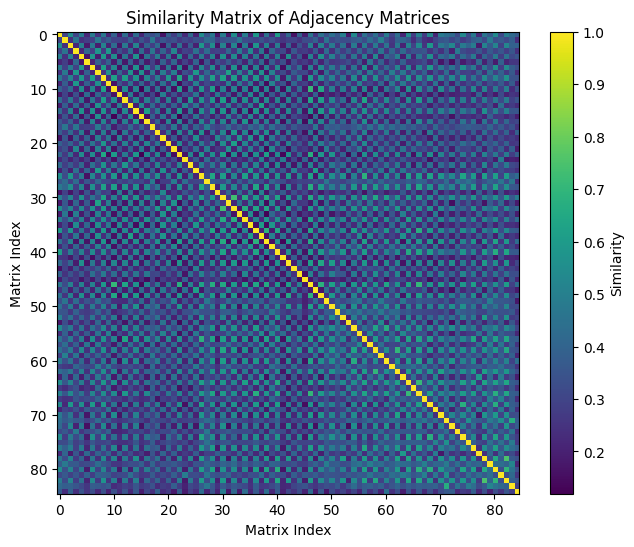

In [59]:
# Plot the similarity matrix
plt.figure(figsize=(8, 6))
plt.imshow(similarity_matrix, cmap='viridis', interpolation='nearest')
plt.colorbar(label='Similarity')
plt.title('Similarity Matrix of Adjacency Matrices')
plt.xlabel('Matrix Index')
plt.ylabel('Matrix Index')
plt.show()

## With History Node

In [60]:
### Adding the History node to the network
edge_weights_with_history_node_list = []
for weighted_matrix in edge_weights:
    # Add a row and column for the new node
    new_node_row = torch.zeros(1, all_connectivity_matrices[0].shape[0], dtype=torch.float)
    new_node_col = torch.zeros(all_connectivity_matrices[0].shape[0]+1, 1, dtype=torch.float)
    
    # Concatenate the new node row and column to the existing matrix
    weighted_matrix = torch.cat([weighted_matrix, new_node_row], dim=0)
    weighted_matrix = torch.cat([weighted_matrix, new_node_col], dim=1)
    
    # Set the connections for the new node
    weighted_matrix[-1, :] = 1  # new node is not connected to all other nodes
    weighted_matrix[:, -1] = 1  # all other nodes are connected to the new node
    weighted_matrix[-1,-1] =1
    
    # Append the modified matrix to the new list
    edge_weights_with_history_node_list.append(weighted_matrix)



adj_with_history_node_list = []
for adj_matrix in adj_orig_dense_list:
    # Add a row and column for the new node
    new_node_row = torch.zeros(1, all_connectivity_matrices[0].shape[0], dtype=torch.float)
    new_node_col = torch.zeros(all_connectivity_matrices[0].shape[0]+1, 1, dtype=torch.float)
    
    # Concatenate the new node row and column to the existing matrix
    adj_matrix = torch.cat([adj_matrix, new_node_row], dim=0)
    adj_matrix = torch.cat([adj_matrix, new_node_col], dim=1)
    
    # Set the connections for the new node
    adj_matrix[-1, :] = 1  # new node is not connected to all other nodes
    adj_matrix[:, -1] = 1  # all other nodes are connected to the new node
    adj_matrix[-1,-1] =1
    
    # Append the modified matrix to the new list
    adj_with_history_node_list.append(adj_matrix)

In [ ]:
adj_time_list_with_history_node = [sp.csr_matrix(adj_matrix) for adj_matrix in adj_with_history_node_list ]


# ## Node attributes (if you want to use Identity Matrix, use the commented lines)
# x_in = Variable(torch.stack(edge_weights_with_history_node_list))


seq_len = len(edge_weights_with_history_node_list)
x_in_list = []
for i in range(0, seq_len):
    x_temp = torch.tensor(np.eye(adj_with_history_node_list[0].shape[0]).astype(np.float32))
    x_in_list.append(torch.tensor(x_temp))

x_in = Variable(torch.stack(x_in_list))

In [62]:
### creating edge list
all_edges = extract_edges(adj_time_list_with_history_node)
edge_idx_list = []

for i in range(len(all_edges)):
    edge_idx_list.append(torch.tensor(np.transpose(all_edges[i]), dtype=torch.long))

In [63]:
len(adj_time_list)

85

In [293]:
# Define hyperparameters
h_dim = 32
z_dim = 8
n_layers = 1
clip = 10
learning_rate = 1e-2
seq_len = len(adj_time_list)
num_nodes = x_in[0].shape[0]
x_dim = num_nodes
eps = 1e-10
conv_type = 'GCN'

In [294]:
model = T_AVRNN(x_dim, h_dim, z_dim, n_layers, eps, bias=True)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [295]:
last_loss = 0
for k in range(20):
    optimizer.zero_grad()
    kld_loss, nll_loss, all_z, all_att_w,all_h = model(x_in, edge_idx_list, adj_with_history_node_list)
    loss = kld_loss + nll_loss
    # loss = nll_loss
    loss.backward()
    optimizer.step()

    
    print('Epoch:', k)
    print('KLD Loss:', kld_loss.mean().item())
    print('NLL Loss:', nll_loss.mean().item())
    print('Total Loss:', loss.mean().item())
    print('-------------------------')
    diff = np.abs(last_loss - loss.mean().item())
    last_loss = loss.mean().item()

Epoch: 0
KLD Loss: 0.1163848340511322
NLL Loss: 72.07846069335938
Total Loss: 72.1948471069336
-------------------------
Epoch: 1
KLD Loss: 0.1654035747051239
NLL Loss: 66.85659790039062
Total Loss: 67.02200317382812
-------------------------
Epoch: 2
KLD Loss: 0.529790461063385
NLL Loss: 63.037132263183594
Total Loss: 63.56692123413086
-------------------------
Epoch: 3
KLD Loss: 0.8234683871269226
NLL Loss: 62.392181396484375
Total Loss: 63.21564865112305
-------------------------
Epoch: 4
KLD Loss: 0.5006029605865479
NLL Loss: 59.62312698364258
Total Loss: 60.12372970581055
-------------------------
Epoch: 5
KLD Loss: 0.4941020607948303
NLL Loss: 58.455326080322266
Total Loss: 58.94942855834961
-------------------------
Epoch: 6
KLD Loss: 0.7051896452903748
NLL Loss: 57.09072494506836
Total Loss: 57.79591369628906
-------------------------
Epoch: 7
KLD Loss: 1.1513841152191162
NLL Loss: 55.041805267333984
Total Loss: 56.19318771362305
-------------------------
Epoch: 8
KLD Loss: 1.7

In [296]:
model.eval()
with torch.no_grad():
    _, _,final_z,_,_ = model(x_in, edge_idx_list ,adj_with_history_node_list)

In [297]:
len(final_z)

85

In [300]:

big_array = np.concatenate([tensor.detach().numpy() for tensor in final_z], axis=0)


In [301]:
# Get the indices which are multiples of 121 (last row of each initial array)
history_indices = np.arange(num_nodes, len(big_array) + 1, num_nodes) - 1

In [302]:
# Use TSNE to map the big array to 3D space
tsne = TSNE(n_components=2,perplexity=50, random_state=42)
mapped_data = tsne.fit_transform(big_array)

In [303]:
# # Extract the corresponding rows from the TSNE output
history_node_embedding = big_array[history_indices]

In [304]:
all_nodes_exclude_hist = np.delete(mapped_data, history_indices,axis=0)

In [305]:
reshaped_all_nodes_exclude_hist = all_nodes_exclude_hist.reshape(len(final_z), num_nodes-1, -1)

avg_all_nodes_exclude_hist = reshaped_all_nodes_exclude_hist.mean(axis=1)

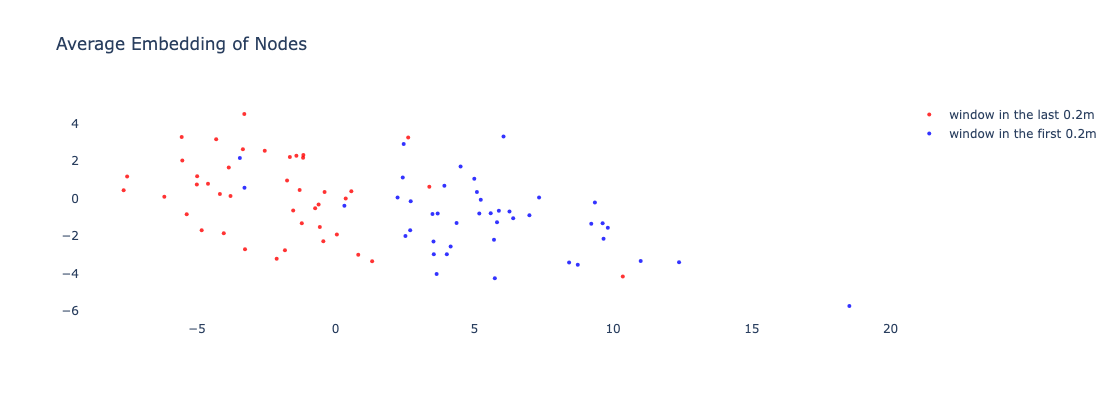

In [311]:
# cmap = ListedColormap(['red', 'blue', 'green', 'orange', 'purple', 'cyan', 'magenta', 'yellow'])
cmap = ListedColormap(['red', 'blue'])

# Prepare the data
embedding_data = np.array(avg_all_nodes_exclude_hist)
labels = np.array(window_labels)[sample_index]

# Create an empty figure
fig = go.Figure()

# Define the colors manually (ensure they match the cmap order)
colors = ['red', 'blue']

# Add a scatter trace for each unique label
unique_labels = np.unique(labels)
for i, label in enumerate(unique_labels):
    indices = np.where(labels == label)
    # Actual data points
    if label ==-1:
        fig.add_trace(go.Scatter(
            x=embedding_data[indices, 0].flatten(),
            y=embedding_data[indices, 1].flatten(),
            mode='markers',
            marker=dict(size=4, color=colors[i], opacity=0.8),
            name=f'window in the last 0.2m ', 
            showlegend=True  # Hide the legend for the actual data points
        ))
    else:
        fig.add_trace(go.Scatter(
        x=embedding_data[indices, 0].flatten(),
        y=embedding_data[indices, 1].flatten(),
        mode='markers',
        marker=dict(size=4, color=colors[i], opacity=0.8),
        name=f'window in the first 0.2m ', 
        showlegend=True  # Hide the legend for the actual data points
    
        ))

# Update the layout to change figure size and background color
fig.update_layout(
    title="Average Embedding of Nodes",
    # legend_title="Windows",
    showlegend=True,
    width=500,  # Set the figure width
    height=400,  # Set the figure height
    plot_bgcolor='rgba(0,0,0,0)',  # Set the plot background color (transparent)
    paper_bgcolor='rgba(255,255,255,1)',  # Set the paper background color (white)
)

# Show the plot
fig.show()

## DishBrain Data

In [64]:
channels = pd.read_pickle('./DataFrames/channel_info')
channels

,channel,side,region,subregion,region_side
91,0,left,0,sensory,10
0,1,right,1,right1,-10
92,2,left,0,sensory,10
422,3,right,1,right1,-10
741,4,left,2,left2,-5
...,...,...,...,...,...
420,1019,right,2,right2,-10
102,1020,left,0,sensory,10
421,1021,right,0,sensory,10
63,1022,left,0,sensory,10


In [65]:
channel_labels = channels['region_side'].values
subregion_labels = channels['subregion'].values

In [66]:
sens_channels = np.array(channels[channels['subregion']=='sensory']['channel'])
motor_channels = channels[(channels['subregion']=='right1') | (channels['subregion']=='right2') | (channels['subregion']=='left1') | (channels['subregion']=='left2')]['channel']

motor_channels_1 = np.array(channels[(channels['subregion']=='right1')| (channels['subregion']=='right2') ]['channel'])
motor_channels_2 = np.array(channels[(channels['subregion']=='left1')|(channels['subregion']=='left2')]['channel'])


In [67]:
df_firing_stats = pd.read_pickle('./DataFrames/sliding_firing_stats_w4min')

### Single Chip (all trials aggregated) 

In [ ]:
from scipy.sparse import load_npz
from read_Maxwell_H5 import *
from gameplay_stats_maxwell import *

In [69]:
df_test = pd.read_feather('./DataFrames/firing_stats.feather')
H5s_list = np.load('h5_files.npy')

In [70]:
df_test['filename'] = df_test['chip_id'].astype(str) + '.' + df_test['date'].astype(str) + '.' + df_test['session'].astype(str) + '.h5_spikewords.npz'


In [71]:
# Specify the directory containing .npy files and load channel number files

## For drug files
directory_path = './DataFrames/Spikewords/'
channels_path = './DataFrames/Spikewords/Channel_Nums/'

In [32]:
# Create an empty list to store the loaded matrices
all_trials_rest = []
all_trials_game = []
# all_real_trials_game = []
chipIDs_rest  = []
filenames_rest =[]
filenames_game =[]
chipIDs_game = []
arrays = {}
valid_ids = []

for filename in os.listdir(directory_path):
    if filename.endswith('.npz') and '003' not in filename:
        print(filename)
        filepath = os.path.join(directory_path, filename)
        trial = load_npz(filepath).toarray()
        
        status = df_test[df_test['filename'] == filename]['status'].values[0]
        channel_nums = np.load(channels_path + filename.removesuffix('_spikewords.npz') + '_channel_nums.npy')
        
        if status == 'rest':
            duration = 12000
        elif status == 'full game':
            duration = 24000
        else:
            continue

        # Handle padding and create modified trial directly
        if trial.shape[1] > duration:
            trial = trial[:, :duration]
        else:
            padding = [(0, 0), (0, duration - trial.shape[1])]
            trial = np.pad(trial, padding, mode='constant', constant_values=0)

        modified_trial = np.zeros((1024, duration))
        modified_trial[channel_nums.astype('int')] = trial
        
        if status == 'rest':
            # all_trials_rest.append(modified_trial)
            # chipIDs_rest.append(filename.split('.')[0])
            # filenames_rest.append(filename.removesuffix('.h5_spikewords.npz'))
            pass
            
        elif status == 'full game':
            all_trials_game.append(modified_trial)
            # all_real_trials_game.append(trial)  # Only if necessary
            chipIDs_game.append(filename.split('.')[0])
            filenames_game.append(filename.removesuffix('.h5_spikewords.npz'))
            # pass
        
        # Clean up to free memory
        del trial, modified_trial
        gc.collect()

11618.2021-06-03.1.h5_spikewords.npz
8127.2021-06-17.4.h5_spikewords.npz
8137b.2021-06-19.3.h5_spikewords.npz
9751.2021-06-17.1.h5_spikewords.npz
7282a.2021-03-11.1.h5_spikewords.npz
9353.2021-06-07.4.h5_spikewords.npz
7963x.2021-06-19.4.h5_spikewords.npz
9431.2021-04-22.2.h5_spikewords.npz
8137b.2021-06-20.2.h5_spikewords.npz
9353.2021-06-11.4.h5_spikewords.npz
7278.2021-02-19.1.h5_spikewords.npz
9353.2021-06-07.2.h5_spikewords.npz
9495.2021-06-11.0.h5_spikewords.npz
8751.2021-04-20.1.h5_spikewords.npz
7963x.2021-06-18.6.h5_spikewords.npz
9323.2021-04-23.3.h5_spikewords.npz
8127.2021-06-18.0.h5_spikewords.npz
7282a.2021-03-04.1.h5_spikewords.npz
9358.2021-06-15.4.h5_spikewords.npz
11619.2021-06-01.0.h5_spikewords.npz
7890.2021-03-02.2.h5_spikewords.npz
11614.2021-05-31.4.h5_spikewords.npz
8751.2021-04-23.3.h5_spikewords.npz
8225x.2021-06-18.1.h5_spikewords.npz
11621.2021-06-01.1.h5_spikewords.npz
9495.2021-06-02.2.h5_spikewords.npz
9495.2021-06-18.4.h5_spikewords.npz
11621.2021-06-02.

In [ ]:
aggregated_all_trials_rest = []
data_to_clean_rest = all_trials_rest
common_strings_rest = set([filename.split('.')[0] for filename in filenames_rest])
for common_string in common_strings_rest:
    # Find all filenames with the same common string
    matching_filenames = [filename for filename in filenames_rest if (filename.split('.')[0] == common_string)]
    # Get the corresponding arrays
    matching_arrays = []
    for filename in matching_filenames:
        df = load_gameplay_stats_maxwell(filename)
        if  (len(df)>1):
            # print("test = ", df['elapse_seconds'].values[-1])
            if (np.abs(df['elapse_seconds'].values[-1] - 300) > np.abs(df['elapse_seconds'].values[-1] - 600)):
                matching_arrays.append(data_to_clean_rest[filenames_rest.index(filename)])
    temp = np.where(sum(matching_arrays) != 0, 1, 0)
    aggregated_all_trials_rest.append(temp)

In [ ]:
aggregated_all_trials_game = []
data_to_clean = all_trials_game
common_strings = set([filename.split('.')[0] for filename in filenames_game])
for common_string in common_strings:
    # Find all filenames with the same common string
    matching_filenames = [filename for filename in filenames_game if (filename.split('.')[0] == common_string)]
    # Get the corresponding arrays
    matching_arrays = []
    for filename in matching_filenames:
        df = load_gameplay_stats_maxwell(filename)
        if  (len(df)>1):
            # print("test = ", df['elapse_seconds'].values[-1])
            if (np.abs(df['elapse_seconds'].values[-1] - 600) > np.abs(df['elapse_seconds'].values[-1] - 1200)):
                matching_arrays.append(data_to_clean[filenames_game.index(filename)])
    temp = np.where(sum(matching_arrays) != 0, 1, 0)
    aggregated_all_trials_game.append(temp)

In [72]:
print(len(sens_channels),len(motor_channels_1),len(motor_channels_2))

626 199 199


In [73]:
all_possible_channels = list(sens_channels) + list(motor_channels_1) + list(motor_channels_2)

In [74]:
channel_locs = pd.read_csv('channel_locs.csv')
all_available_channels = list(channel_locs['channel'].values)

In [75]:
all_available_channels_labels = channel_labels[all_available_channels]
all_available_subregion_labels = subregion_labels[all_available_channels]

In [76]:
all_missing_channels = [val for val in all_possible_channels if val not in all_available_channels]
all_available_sens_channel = [val for val in sens_channels if val not in all_missing_channels]
all_available_motor_1_channel = [val for val in motor_channels_1 if val not in all_missing_channels]
all_available_motor_2_channel = [val for val in motor_channels_2 if val not in all_missing_channels]
print(len(all_available_sens_channel),len(all_available_motor_1_channel),len(all_available_motor_2_channel))

502 199 199


In [77]:
sens_labels_loc = np.where(all_available_channels_labels==10)[0]
mot_1_labels_loc = np.where(all_available_channels_labels==-10)[0]
mot_2_labels_loc = np.where(all_available_channels_labels==-5)[0]

mot_r1_labels_loc = np.where(all_available_subregion_labels=='right1')[0]
mot_r2_labels_loc = np.where(all_available_subregion_labels=='right2')[0]

mot_l1_labels_loc = np.where(all_available_subregion_labels=='left1')[0]
mot_l2_labels_loc = np.where(all_available_subregion_labels=='left2')[0]

In [78]:
x_coordinate = channel_locs['x'].values
y_coordinate = channel_locs['y'].values
channel_loc_id = channel_locs['channel'].values

In [79]:
sens_indices = [i for i, val in enumerate(channel_loc_id) if val in sens_channels]
motor_1_indices = [i for i, val in enumerate(channel_loc_id) if val in motor_channels_1]
motor_2_indices = [i for i, val in enumerate(channel_loc_id) if val in motor_channels_2]

motor_left_1_indices = [i for i, val in enumerate(channel_loc_id) if val in channels[channels['subregion']=='left1']['channel'].values]
motor_left_2_indices = [i for i, val in enumerate(channel_loc_id) if val in channels[channels['subregion']=='left2']['channel'].values]

motor_right_1_indices = [i for i, val in enumerate(channel_loc_id) if val in channels[channels['subregion']=='right1']['channel'].values]
motor_right_2_indices = [i for i, val in enumerate(channel_loc_id) if val in channels[channels['subregion']=='right2']['channel'].values]

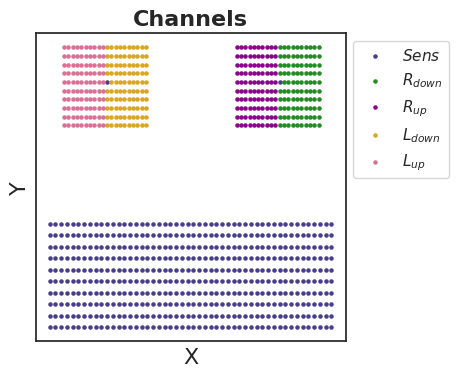

In [81]:
# Plot the points with labels
sns.set(style='white')
fig = plt.figure(figsize=(4, 4))

palette = ['darkslateblue', 'forestgreen', 'darkmagenta', 'goldenrod', 'palevioletred']
groups = ['$Sens$', r'$R_{down}$', '$R_{up}$', '$L_{down}$', '$L_{up}$']

# Plot all points with the same color
pointsize=5
# plt.scatter(x_coordinate, y_coordinate, c='blue', label='All Points',s=pointsize)
plt.scatter(x_coordinate[sens_indices], y_coordinate[sens_indices], c=palette[0], label=groups[0],s=pointsize)
# plt.scatter(x_coordinate[motor_1_indices], y_coordinate[motor_1_indices], c='red', label='All Points',s=pointsize)
# plt.scatter(x_coordinate[motor_2_indices], y_coordinate[motor_2_indices], c='green', label='All Points',s=pointsize)

plt.scatter(x_coordinate[motor_right_1_indices], y_coordinate[motor_right_1_indices], c=palette[1], label=groups[1],s=pointsize)
plt.scatter(x_coordinate[motor_right_2_indices], y_coordinate[motor_right_2_indices], c=palette[2], label=groups[2],s=pointsize)
plt.scatter(x_coordinate[motor_left_1_indices], y_coordinate[motor_left_1_indices], c=palette[3], label=groups[3],s=pointsize)
plt.scatter(x_coordinate[motor_left_2_indices], y_coordinate[motor_left_2_indices], c=palette[4], label=groups[4],s=pointsize)

# Annotate each point with its label
# for i, (x, y) in enumerate(zip(x_coordinate, y_coordinate)):
#     plt.text(x, y, str(channel_loc_id[i]), color='black', fontsize=7, ha='center', va='bottom')

plt.xlabel('X',fontsize=16)
plt.ylabel('Y',fontsize=16)
plt.title('Channels',fontsize=16,weight='bold')

plt.xticks([])  
plt.yticks([])
# plt.legend()
# plt.grid(True)

# plt.tight_layout()

# Add a legend
plt.legend(frameon=True, loc='upper left', bbox_to_anchor=(1, 1))

plt.show()






In [82]:
chip_id = '8137b'

In [83]:
# np.save('./sample data/neural_data_9501.npy', neural_data)
neural_data = np.load('./sample data/neural_data_'+chip_id+'.npy')

In [84]:
neural_data.shape

(900, 24000)

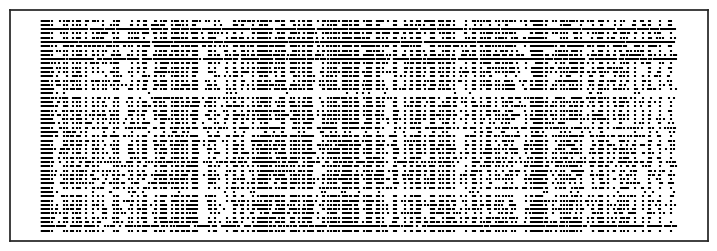

In [85]:
spike_indices = np.nonzero(neural_data[0:50])
plt.figure(figsize=(9, 3))
plt.scatter(spike_indices[1], spike_indices[0], marker='|', color='black',s=3)
# plt.xlabel('Time Steps')
# plt.ylabel('Units')
# plt.title('Raster Plot')
plt.xticks([])  
plt.yticks([])
plt.show()

In [86]:
all_files = np.load('h5_files.npy')

In [87]:
common_strings_all_files = [filename.split('.')[0] for filename in all_files]

In [88]:
common_indices = [index for index, element in enumerate(common_strings_all_files) if element == '8137b']

In [ ]:
############## gameplay ##################
all_hits = []
all_files_ind = []
for ind in common_indices:
    if int(all_files[ind].removesuffix('.h5').split('.')[-1])%2 ==0:
        df = load_gameplay_stats_maxwell(all_files[ind])
        if  (len(df)>1): 
            if (np.abs(df['elapse_seconds'].values[-1] - 600) > np.abs(df['elapse_seconds'].values[-1] - 1200)):
                all_files_ind.append(all_files[ind])
                all_hits.append(df['hit_count'].values)


############## rest ##################
# all_hits = []
# all_files_ind = []
# for ind in common_indices:
#     if int(all_files[ind].removesuffix('.h5').split('.')[-1])%2 ==1:
#         df = load_gameplay_stats_maxwell(all_files[ind])
#         if  (len(df)>1): 
#             if (np.abs(df['elapse_seconds'].values[-1] - 300) > np.abs(df['elapse_seconds'].values[-1] - 600)):
#                 all_files_ind.append(all_files[ind])
#                 all_hits.append(df['hit_count'].values)

In [90]:
all_files_ind

['8137b.2021-06-17.0.h5',
 '8137b.2021-06-17.2.h5',
 '8137b.2021-06-17.4.h5',
 '8137b.2021-06-18.0.h5',
 '8137b.2021-06-18.2.h5',
 '8137b.2021-06-18.4.h5',
 '8137b.2021-06-19.0.h5',
 '8137b.2021-06-19.2.h5',
 '8137b.2021-06-19.4.h5',
 '8137b.2021-06-20.0.h5',
 '8137b.2021-06-20.2.h5',
 '8137b.2021-06-20.4.h5']

In [ ]:
############## gameplay ##################
fs = 20000
all_trials_hit_nums = np.zeros(24000)

for ind in all_files_ind:
# for ind in ['9501.2021-05-31.0.h5']:
    df = load_gameplay_stats_maxwell(ind)
    episode_ends_sec = df['elapse_seconds'].values
    temp  = (episode_ends_sec * fs) / (50*1e-3*fs)
    episode_ends_ind = [math.ceil(x) for x in temp]
    
    start = 0
    for i in range(len(episode_ends_ind)):
        all_trials_hit_nums[start : episode_ends_ind[i]] += df['hit_count'].values[i]
        start = episode_ends_ind[i]


############## rest ##################
# fs = 20000
# all_trials_hit_nums = np.zeros(12000)

# for ind in all_files_ind:
#     df = load_gameplay_stats_maxwell(ind)
#     episode_ends_sec = df['elapse_seconds'].values
#     temp  = (episode_ends_sec * fs) / (50*1e-3*fs)
#     episode_ends_ind = [math.ceil(x) for x in temp]
    
#     start = 0
#     for i in range(len(episode_ends_ind)):
#         all_trials_hit_nums[start : episode_ends_ind[i]] += df['hit_count'].values[i]
#         start = episode_ends_ind[i]

In [348]:
num_timepoints = np.shape(neural_data)[1]

window_size = 2400
step_size = int(window_size/2)  # Choose a step size (overlap between windows)




dynamic_windows_hits = []
for start in range(0, num_timepoints - window_size + 1, step_size):
    end = start + window_size
    average_all_trials_hit_nums = all_trials_hit_nums/ len(all_files_ind)
    dynamic_windows_hits.append(average_all_trials_hit_nums[start:end].mean())

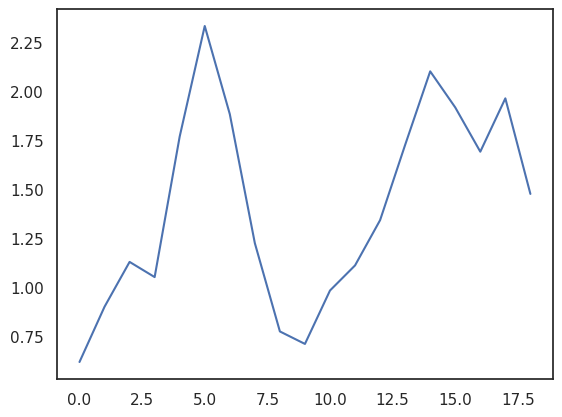

In [349]:
plt.plot(dynamic_windows_hits)

In [199]:
common_strings=['8225x',
 '8790',
 '11613',
 '9431',
 '7278',
 '6542x',
 '9381',
 '11619',
 '9751b',
 '8127ii',
 '11618',
 '9495',
 '8137b',
 '9501',
 '9501i',
 '9751ii',
 '7282a',
 '9323',
 '11615',
 '7890',
 '8137ii',
 '9358',
 '8127',
 '8751',
 '9353',
 '7282',
 '9468',
 '7963x',
 '9751',
 '11614',
 '11621',
 '11623',
 '11597']

In [229]:
# df_chips_final_info = pd.DataFrame()
# all_chips = []
# all_tops = []
# all_bottoms = []
# for chip in common_strings:
    
#     neural_data =sparse.load_npz('./sample data/aggregated_all_trials_game'+ chip +'.npz').toarray()
#     if len(neural_data)>1:
#         neural_data = np.delete(neural_data, all_missing_channels, axis=0)
        
#         common_indices = [index for index, element in enumerate(common_strings_all_files) if element == chip]
        
#         all_hits = []
#         all_files_ind = []
#         for ind in common_indices:
#             if int(all_files[ind].removesuffix('.h5').split('.')[-1])%2 ==0:
#                 df = load_gameplay_stats_maxwell(all_files[ind])
#                 if  (len(df)>1): 
#                     if (np.abs(df['elapse_seconds'].values[-1] - 600) > np.abs(df['elapse_seconds'].values[-1] - 1200)):
#                         all_files_ind.append(all_files[ind])
#                         all_hits.append(df['hit_count'].values)
        
        
#         fs = 20000
#         all_trials_hit_nums = np.zeros(24000)
        
#         for ind in all_files_ind:
#             df = load_gameplay_stats_maxwell(ind)
#             episode_ends_sec = df['elapse_seconds'].values
#             temp  = (episode_ends_sec * fs) / (50*1e-3*fs)
#             episode_ends_ind = [math.ceil(x) for x in temp]
            
#             start = 0
#             for i in range(len(episode_ends_ind)):
#                 all_trials_hit_nums[start : episode_ends_ind[i]] += df['hit_count'].values[i]
#                 start = episode_ends_ind[i]
        
#         num_timepoints = np.shape(neural_data)[1]
        
#         window_size = 2400 
#         step_size = int(window_size/2)  # Choose a step size (overlap between windows)
        
        
        
        
#         dynamic_windows_hits = []
#         for start in range(0, num_timepoints - window_size + 1, step_size):
#             end = start + window_size
#             average_all_trials_hit_nums = all_trials_hit_nums/ len(all_files_ind)
#             dynamic_windows_hits.append(average_all_trials_hit_nums[start:end].mean())


#         # Get indices of the 5 largest values
#         top_max_indices = np.array(dynamic_windows_hits).argsort()[-5:][::-1]
        
#         # Get indices of the 5 smallest values
#         bottom_min_indices = np.array(dynamic_windows_hits).argsort()[:5]
        
#         # local_max_indices = argrelextrema(np.array(dynamic_windows_hits), np.greater)[0]
#         # local_min_indices = argrelextrema(np.array(dynamic_windows_hits), np.less)[0]  
#         # # Step 4: Sort and select top 10 maxima and bottom 10 minima
#         # top_max_indices = local_max_indices[np.argsort(np.array(dynamic_windows_hits)[local_max_indices])][-10:]
#         # bottom_min_indices = local_min_indices[np.argsort(np.array(dynamic_windows_hits)[local_min_indices])][:10]

#         all_chips.append(chip)
#         all_tops.append(np.array(dynamic_windows_hits)[top_max_indices])
#         all_bottoms.append(np.array(dynamic_windows_hits)[bottom_min_indices])
        
# df_chips_final_info['chip_id'] = all_chips
# df_chips_final_info['top_indices_values'] = all_tops
# df_chips_final_info['bottom_indices_values'] = all_bottoms

In [204]:
df_chips_final_info

,chip_id,top_indices_values,bottom_indices_values
0,8225x,"[1.4601388888888887, 1.4484722222222222, 1.434...","[0.7831018518518518, 0.8632407407407405, 0.907..."
1,8790,"[4.940833333333333, 3.476875, 2.53458333333333...","[0.3614583333333333, 0.6464583333333334, 0.671..."
2,11613,"[1.8358333333333334, 1.6918055555555556, 1.586...","[0.3983333333333333, 0.56125, 0.71583333333333..."
3,9431,"[2.578125, 1.900138888888889, 1.76430555555555...","[0.6571875, 0.7419444444444444, 0.792048611111..."
4,7278,"[17.116875, 16.940694444444446, 8.926875, 7.95...","[0.4534027777777778, 0.524236111111111, 0.6154..."
5,6542x,"[2.020694444444444, 1.78, 1.6947916666666667, ...","[0.8168749999999999, 0.8382638888888888, 0.903..."
6,9381,"[1.2946296296296298, 1.2552314814814816, 1.201...","[0.7461574074074073, 0.7630555555555555, 0.851..."
7,11619,"[2.098611111111111, 2.0185648148148143, 1.6955...","[0.6545833333333333, 0.6858796296296297, 0.856..."
8,9751b,"[4.8, 4.274305555555556, 2.4816666666666665, 2...","[0.7755555555555557, 0.7936111111111113, 0.804..."
9,8127ii,"[7.318680555555555, 6.066458333333332, 3.95736...","[0.4481944444444444, 0.525, 0.5418055555555555..."


In [218]:
df_stats_high = df_chips_final_info.copy()
df_stats_low = df_chips_final_info.copy()
df_stats = df_chips_final_info.copy()
# Reverse the order in the "top_indices_values" column
df_stats['top_indices_values'] = df_stats['top_indices_values'].apply(lambda x: x[::-1])

# Keep only the first three elements in both columns
df_stats['top_indices_values'] = df_stats['top_indices_values'].apply(lambda x: x[-3:])
df_stats['bottom_indices_values'] = df_stats['bottom_indices_values'].apply(lambda x: x[:3])


array([0.78310185, 0.86324074, 0.90736111])

In [225]:
# Create the rank labels for the corresponding values
rank_labels_top = [r'High$^3$', r'High$^2$', r'High$^1$']
rank_labels_bottom = [r'Low$^1$', r'Low$^2$', r'Low$^3$']

# Initialize an empty dataframe for the final output
final_df = pd.DataFrame(columns=['rank', 'value'])

# Loop through each row and append the corresponding values and ranks
for index, row in df_stats.iterrows():
    # Create a dictionary for top and bottom values
    top_values = row['top_indices_values']
    bottom_values = row['bottom_indices_values']
    
    # Create dataframes for top and bottom values with corresponding ranks
    top_df = pd.DataFrame({'rank': rank_labels_top, 'value': top_values})
    bottom_df = pd.DataFrame({'rank': rank_labels_bottom, 'value': bottom_values})
    
    # Append the result to the final dataframe
    final_df = pd.concat([final_df, top_df, bottom_df], ignore_index=True)

final_df

/tmp/ipykernel_671049/3156948360.py:19: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  final_df = pd.concat([final_df, top_df, bottom_df], ignore_index=True)


,rank,value
0,High$^3$,1.434444
1,High$^2$,1.448472
2,High$^1$,1.460139
3,Low$^1$,0.783102
4,Low$^2$,0.863241
...,...,...
193,High$^2$,1.631667
194,High$^1$,1.634583
195,Low$^1$,0.103472
196,Low$^2$,0.249722


/tmp/ipykernel_671049/1144372226.py:15: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.lineplot(data=low_data, x='rank', y='value', label='Low Ranks', marker='o', ci=95,legend=False,err_style="bars",c='darkolivegreen')
/tmp/ipykernel_671049/1144372226.py:20: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.lineplot(data=high_data, x='rank', y='value', label='High Ranks', marker='o', ci=95,legend=False,err_style="bars",c='darkmagenta')


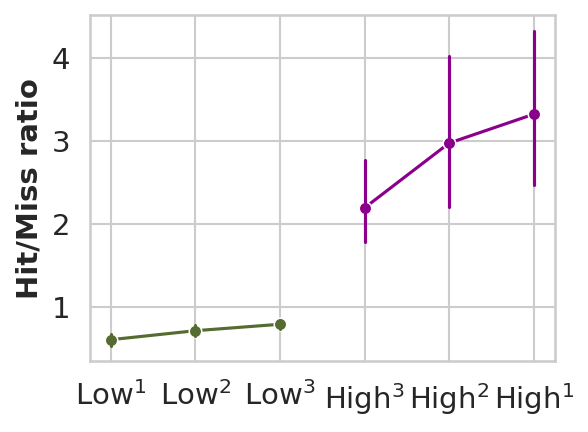

In [230]:
import seaborn as sns
import matplotlib.pyplot as plt

# Setting style
sns.set(style="whitegrid", font_scale=1.5)

# Separate data for 'High' and 'Low' ranks
high_data = final_df[final_df['rank'].str.startswith('High')]
low_data = final_df[final_df['rank'].str.startswith('Low')]

# Plotting
plt.figure(figsize=(4, 3), dpi=150)

# Plot for 'Low' ranks with confidence intervals
sns.lineplot(data=low_data, x='rank', y='value', label='Low Ranks', marker='o', ci=95,legend=False,err_style="bars",c='darkolivegreen')

# Plot for 'High' ranks with confidence intervals, reversing order of ranks
# high_data_sorted = high_data.iloc[::-1]  # Assuming you want to reverse the plot order
# sns.lineplot(data=high_data_sorted, x='rank', y='value', label='High Ranks', marker='o', ci=95,legend=False,err_style="bars",c='darkmagenta')
sns.lineplot(data=high_data, x='rank', y='value', label='High Ranks', marker='o', ci=95,legend=False,err_style="bars",c='darkmagenta')

# Labeling and Styling
plt.xlabel('', fontsize=14, fontweight="bold")
# Assuming 'titlee' variable is defined, replace 'titlee' with the actual variable if different
plt.ylabel(titlee if 'titlee' in locals() else 'Hit/Miss ratio', fontsize=14, fontweight="bold")

# Adjust tick labels
plt.xticks(rotation=0, fontsize=14)
plt.yticks(fontsize=14)

plt.savefig('./ICLR_figs/behaviour_lineplot.pdf', format='pdf',bbox_inches = 'tight')
plt.show()

In [350]:

# Get indices of the 5 largest values
top_max_indices = np.array(dynamic_windows_hits).argsort()[-5:][::-1]

# Get indices of the 5 smallest values
bottom_min_indices = np.array(dynamic_windows_hits).argsort()[:5]

print("Indices of the 5 largest values:", top_max_indices)
print("Indices of the 5 smallest values:", bottom_min_indices)

Indices of the 5 largest values: [ 5 14 17 15  6]
Indices of the 5 smallest values: [ 0  9  8  1 10]


In [134]:
top_max_indices = np.array([5,  14, 17])
bottom_min_indices = np.array([ 0,  9, 8])


In [135]:
rec_length = 20 # in minutes


num_timepoints = np.shape(neural_data)[1]

# Set parameters for sliding windows
window_size = 2400
step_size = int(window_size/2)  # Choose a step size (overlap between windows)


# Create a list to store dynamic functional connectivity networks

dynamic_networks = []

all_connectivity_matrices = []
for start in range(0, num_timepoints - window_size + 1, step_size):
    end = start + window_size

    current_window = neural_data[:, start:end]


    current_window[np.isnan(current_window)] = 0
    connectivity_matrix = np.corrcoef(current_window)
    connectivity_matrix[np.isnan(connectivity_matrix)] = 0
    

    np.fill_diagonal(connectivity_matrix, 1)
      
    all_connectivity_matrices.append(connectivity_matrix)

In [136]:
len(all_connectivity_matrices)

19

In [137]:
sampled_local_optima_indices = list(top_max_indices) + list(bottom_min_indices)

In [138]:
re_organized_connectivity_matrices = []

for i in range(len(all_connectivity_matrices)):
    # new_order = np.concatenate((sens_labels_loc, mot_1_labels_loc, mot_2_labels_loc))
    new_order = np.concatenate((sens_labels_loc, mot_r1_labels_loc, mot_r2_labels_loc, mot_l1_labels_loc, mot_l2_labels_loc))
    
    re_organized_matrix_4 = np.abs(all_connectivity_matrices[i])[new_order]
    re_organized_matrix_4 = re_organized_matrix_4[:, new_order]
    
    re_organized_connectivity_matrices.append(re_organized_matrix_4.copy())


In [144]:
sample_index = np.arange(0,len(all_connectivity_matrices))
sample_index = sampled_local_optima_indices
# sample_index = np.sort(sampled_local_optima_indices)
sample_index 

[5, 14, 17, 0, 9, 8]

In [151]:
# sampled_connectivity_matrices = np.array(all_connectivity_matrices)[sample_index]
sampled_connectivity_matrices = np.array(re_organized_connectivity_matrices)[sample_index]

In [146]:
adj_time_list = [sp.csr_matrix(connectivity_mat) for  connectivity_mat in sampled_connectivity_matrices]

In [147]:
len(adj_time_list)

6

In [148]:
num_nodes = np.shape(adj_time_list[0])[0]

In [149]:
### Weighted Adjacency Matrix
threshold = 0.6
edge_weights = [torch.tensor(np.abs(np.where(np.abs(connectivity_matrix.toarray()) < 0, 0, connectivity_matrix.toarray())), dtype=torch.float32) for connectivity_matrix in adj_time_list]

edge_weights_threshold = [torch.tensor(np.abs(np.where(np.abs(connectivity_matrix.toarray()) < threshold, 0, connectivity_matrix.toarray())), dtype=torch.float32) for connectivity_matrix in adj_time_list]

### Binary Adjacency Matrix
adj_orig_dense_list = [(weighted_matrix != 0).int() for weighted_matrix in edge_weights_threshold] 

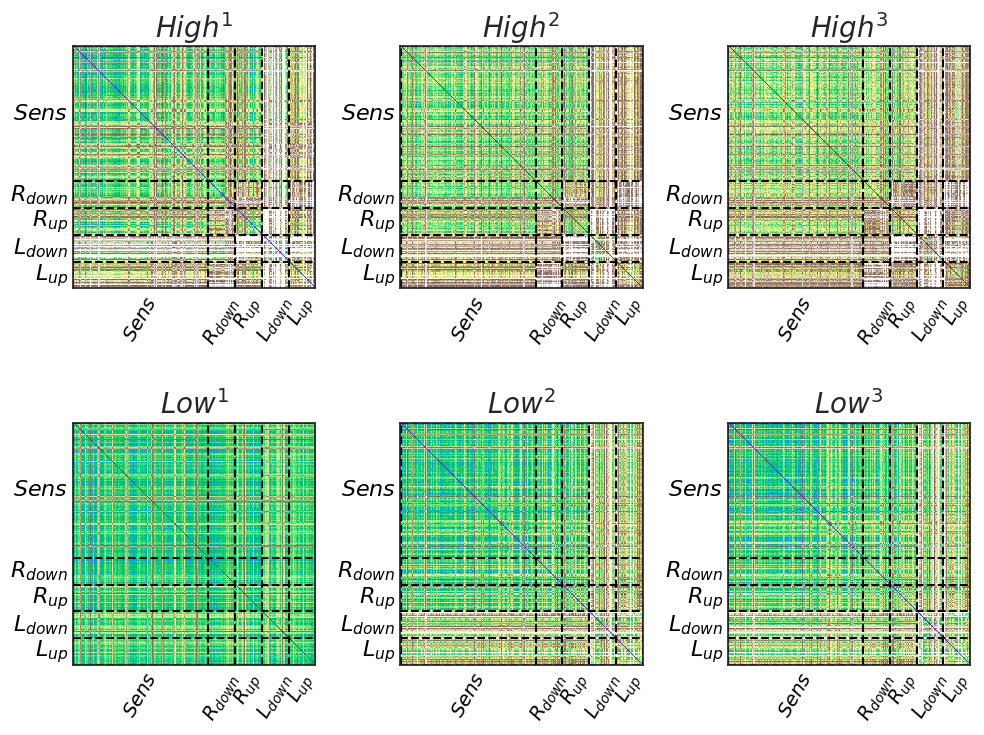

In [150]:
fig = plt.figure(figsize=(10, 10))
# fig = plt.figure(figsize=(15, 60))

horizontal_indices = [0,len(all_available_sens_channel), len(all_available_sens_channel) + len(mot_r1_labels_loc),
                      len(all_available_sens_channel) + len(mot_r1_labels_loc) + len(mot_r2_labels_loc),
                      len(all_available_sens_channel) + len(mot_r1_labels_loc) + len(mot_r2_labels_loc) + len(
                          mot_l1_labels_loc),900]
vertical_indices = horizontal_indices  # Example vertical indices

j = 0
for i in range(len(edge_weights)):
    adjacency_matrix_array = edge_weights[i].numpy()
    
    ax = fig.add_subplot(2, 3, j + 1)
    j += 1
    plotting.plot_matrix(adjacency_matrix_array, figure=fig, colorbar=False, vmax=1, vmin=0, cmap='terrain_r')
    
    for idx in vertical_indices:
        ax.axvline(idx, color='black', linewidth=1.5, linestyle='--')

    for idx in horizontal_indices:
        ax.axhline(idx, color='black', linewidth=1.5, linestyle='--')
    
    # Calculate midpoints for text labels
    midpoints_horizontal = np.array([(horizontal_indices[i] + horizontal_indices[i + 1]) / 2 for i in range(len(horizontal_indices) - 1)])
    midpoints_vertical = midpoints_horizontal  # Since it's a square matrix and same divisions
    
    # Labels for each section
    labels = ['$Sens$', r'$R_{down}$', '$R_{up}$', '$L_{down}$', '$L_{up}$']
    
    
    # Adding text to the left and bottom
    for label, midpoint in zip(labels, midpoints_vertical):
        ax.text(-0.02 * ax.get_xlim()[1], midpoint, label, va='center', ha='right', fontsize=16, color='black')
    
    for label, midpoint in zip(labels, midpoints_horizontal):
        ax.text(midpoint,  1.02 * ax.get_ylim()[0], label, va='top', ha='center', fontsize=14, color='black', rotation=60)
        
    ax.set_title(f'window {sample_index[i]}',fontsize=16)
    
    if ((j < 3)): 
        ax.set_title(f'$High^{j}$',fontsize=20,weight='bold')
    elif (j==3):
        ax.set_title(r'$High^{3}$',fontsize=20,weight='bold')
    elif (j==6):
        ax.set_title(r'$Low^{3}$',fontsize=20,weight='bold')
    else:
        ax.set_title(f'$Low^{j-3}$',fontsize=20,weight='bold')

plt.tight_layout()
plt.show()

### Without History node

In [541]:
# ### Node attributes (if you want to use Identity Matrix, use the commented lines)

# x_in = Variable(torch.stack(edge_weights))


# # seq_len = len(edge_weights)
# # x_in_list = []
# # for i in range(0, seq_len):
# #     x_temp = torch.tensor(np.eye(num_nodes).astype(np.float32))      
# #     x_in_list.append(torch.tensor(x_temp))

# # x_in = Variable(torch.stack(x_in_list))


In [542]:
# # creating edge list

# adj_time_list_new = [sp.csr_matrix(adj_matrix) for adj_matrix in adj_orig_dense_list]
# all_edges = extract_edges(adj_time_list_new)
# edge_idx_list = []

# for i in range(len(all_edges)):
#     edge_idx_list.append(torch.tensor(np.transpose(all_edges[i]), dtype=torch.long))

### With History node

In [123]:
### Adding the History node to the network
edge_weights_with_history_node_list = []
for weighted_matrix in edge_weights:
    # Add a row and column for the new node
    new_node_row = torch.zeros(1, all_connectivity_matrices[0].shape[0], dtype=torch.float)
    new_node_col = torch.zeros(all_connectivity_matrices[0].shape[0]+1, 1, dtype=torch.float)
    
    # Concatenate the new node row and column to the existing matrix
    weighted_matrix = torch.cat([weighted_matrix, new_node_row], dim=0)
    weighted_matrix = torch.cat([weighted_matrix, new_node_col], dim=1)
    
    # Set the connections for the new node
    weighted_matrix[-1, :] = 1  # new node is not connected to all other nodes
    weighted_matrix[:, -1] = 1  # all other nodes are connected to the new node
    weighted_matrix[-1,-1] =1
    
    # Append the modified matrix to the new list
    edge_weights_with_history_node_list.append(weighted_matrix)



adj_with_history_node_list = []
for adj_matrix in adj_orig_dense_list:
    # Add a row and column for the new node
    new_node_row = torch.zeros(1, all_connectivity_matrices[0].shape[0], dtype=torch.float)
    new_node_col = torch.zeros(all_connectivity_matrices[0].shape[0]+1, 1, dtype=torch.float)
    
    # Concatenate the new node row and column to the existing matrix
    adj_matrix = torch.cat([adj_matrix, new_node_row], dim=0)
    adj_matrix = torch.cat([adj_matrix, new_node_col], dim=1)
    
    # Set the connections for the new node
    adj_matrix[-1, :] = 1  # new node is not connected to all other nodes
    adj_matrix[:, -1] = 1  # all other nodes are connected to the new node
    adj_matrix[-1,-1] =1
    
    # Append the modified matrix to the new list
    adj_with_history_node_list.append(adj_matrix)

In [124]:
adj_time_list_with_history_node = [sp.csr_matrix(adj_matrix) for adj_matrix in adj_with_history_node_list ]


## Node attributes (if you want to use Identity Matrix, use the commented lines)
x_in = Variable(torch.stack(edge_weights_with_history_node_list))


# seq_len = len(edge_weights_with_history_node_list)
# x_in_list = []
# for i in range(0, seq_len):
#     x_temp = torch.tensor(np.eye(adj_with_history_node_list[0].shape[0]).astype(np.float32))
#     x_in_list.append(torch.tensor(x_temp))

# x_in = Variable(torch.stack(x_in_list))




In [125]:
### creating edge list
all_edges = extract_edges(adj_time_list_with_history_node)
edge_idx_list = []

for i in range(len(all_edges)):
    edge_idx_list.append(torch.tensor(np.transpose(all_edges[i]), dtype=torch.long))

In [126]:
len(edge_idx_list)

19

In [143]:
# Define hyperparameters
h_dim = 32
z_dim = 8
n_layers = 1
clip = 10
learning_rate = 1e-2
seq_len = len(adj_time_list)
num_nodes = x_in[0].shape[0]
x_dim = num_nodes
eps = 1e-10
conv_type = 'GCN'

In [144]:
model = T_AVRNN(x_dim, h_dim, z_dim, n_layers, eps, bias=True)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [145]:
last_loss = 0
for k in range(500):
    optimizer.zero_grad()
    kld_loss, nll_loss, all_z, all_att_w,all_h = model(x_in, edge_idx_list, adj_with_history_node_list)
    loss = kld_loss + nll_loss
    loss.backward()
    optimizer.step()

    
    print('Epoch:', k)
    print('KLD Loss:', kld_loss.mean().item())
    print('NLL Loss:', nll_loss.mean().item())
    print('Total Loss:', loss.mean().item())
    print('-------------------------')
    diff = np.abs(last_loss - loss.mean().item())
    last_loss = loss.mean().item()

Epoch: 0
KLD Loss: 0.016510380432009697
NLL Loss: 16.303693771362305
Total Loss: 16.32020378112793
-------------------------
Epoch: 1
KLD Loss: 2.0389251708984375
NLL Loss: 326.9610290527344
Total Loss: 328.99993896484375
-------------------------
Epoch: 2
KLD Loss: 0.3213149905204773
NLL Loss: 44.561161041259766
Total Loss: 44.882476806640625
-------------------------
Epoch: 3
KLD Loss: 0.2351798564195633
NLL Loss: 35.128456115722656
Total Loss: 35.3636360168457
-------------------------
Epoch: 4
KLD Loss: 0.1951323002576828
NLL Loss: 29.18791961669922
Total Loss: 29.383052825927734
-------------------------
Epoch: 5
KLD Loss: 0.1547541618347168
NLL Loss: 24.970666885375977
Total Loss: 25.12542152404785
-------------------------
Epoch: 6
KLD Loss: 0.1223299577832222
NLL Loss: 20.852291107177734
Total Loss: 20.974620819091797
-------------------------
Epoch: 7
KLD Loss: 0.10800493508577347
NLL Loss: 18.55624008178711
Total Loss: 18.66424560546875
-------------------------
Epoch: 8
KLD 

In [147]:
model.eval()
with torch.no_grad():
    _, _,final_z,_,_ = model(x_in, edge_idx_list ,adj_with_history_node_list)

In [152]:
tsne = TSNE(n_components=2,perplexity=50)

In [153]:
bottom_min_indices

array([0, 9, 8])

In [154]:
top_max_indices

array([ 5, 14, 17])

In [369]:
final_samples = [17,14,5, 0,9,8]

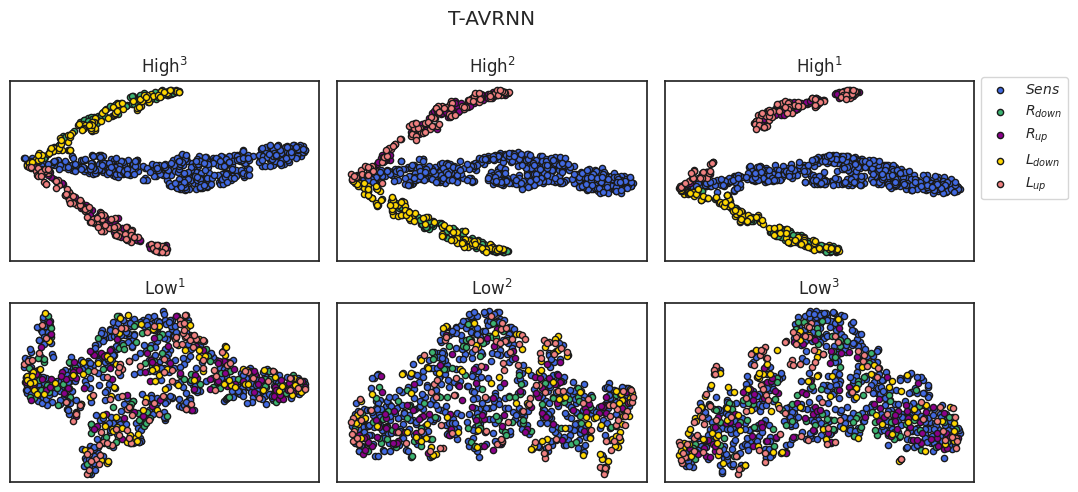

In [372]:
# Set the style for the plot
# sns.set(style='whitegrid')
sns.set(style='white')


fig = plt.figure(figsize=(10, 5))
# Define a color palette
# palette = sns.color_palette()
# palette = ['blue', 'red', 'green', 'black', 'orange']
palette = ['royalblue', 'mediumseagreen', 'darkmagenta', '#FFD700', 'lightcoral']

groups = ['$Sens$', r'$R_{down}$', '$R_{up}$', '$L_{down}$', '$L_{up}$']

j = 0
for i in final_samples:
    # adjacency_matrix_array = edge_weights[i].numpy()
    a = tsne.fit_transform(final_z[i])
    ax = fig.add_subplot(2, 3, j + 1)
    j += 1
    plt.scatter(a[0:x1, 0], a[0:x1, 1], label=groups[0], color=palette[0], s=20, edgecolor='k')
    plt.scatter(a[x1:x2, 0], a[x1:x2, 1], label=groups[1], color=palette[1], s=20, edgecolor='k')
    plt.scatter(a[x2:x3, 0], a[x2:x3, 1], label=groups[2], color=palette[2], s=20, edgecolor='k')
    plt.scatter(a[x3:x4, 0], a[x3:x4, 1], label=groups[3], color=palette[3], s=20, edgecolor='k')
    plt.scatter(a[x4:, 0], a[x4:, 1], label=groups[4], color=palette[4], s=20, edgecolor='k')

    # Title and labels
    # plt.xlabel('Component 1', fontsize=10)
    # plt.ylabel('Component 2', fontsize=10)
    
    plt.xticks([])  
    plt.yticks([])
        
    if ((j < 4)): 
        ax.set_title(f'High$^{4-j}$',fontsize=12)
    else:
        ax.set_title(f'Low$^{j-3}$',fontsize=12)
    plt.suptitle('TAVRNN')

plt.tight_layout()

# Add a legend
plt.legend(frameon=True, loc='upper left', bbox_to_anchor=(1, 2.3), fontsize=10)

plt.show()